# **CNN for digit classification of MNIST Dataset**

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

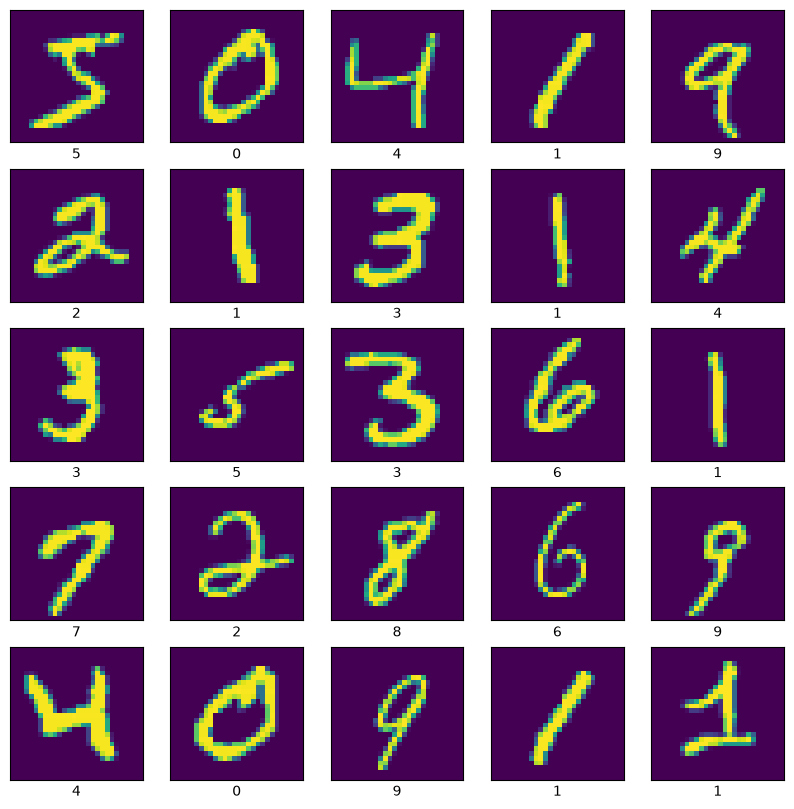

In [3]:
class_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i]), #cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [4]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_train.shape
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_test.shape

(10000, 28, 28, 1)

In [5]:
x_train.shape

(60000, 28, 28, 1)

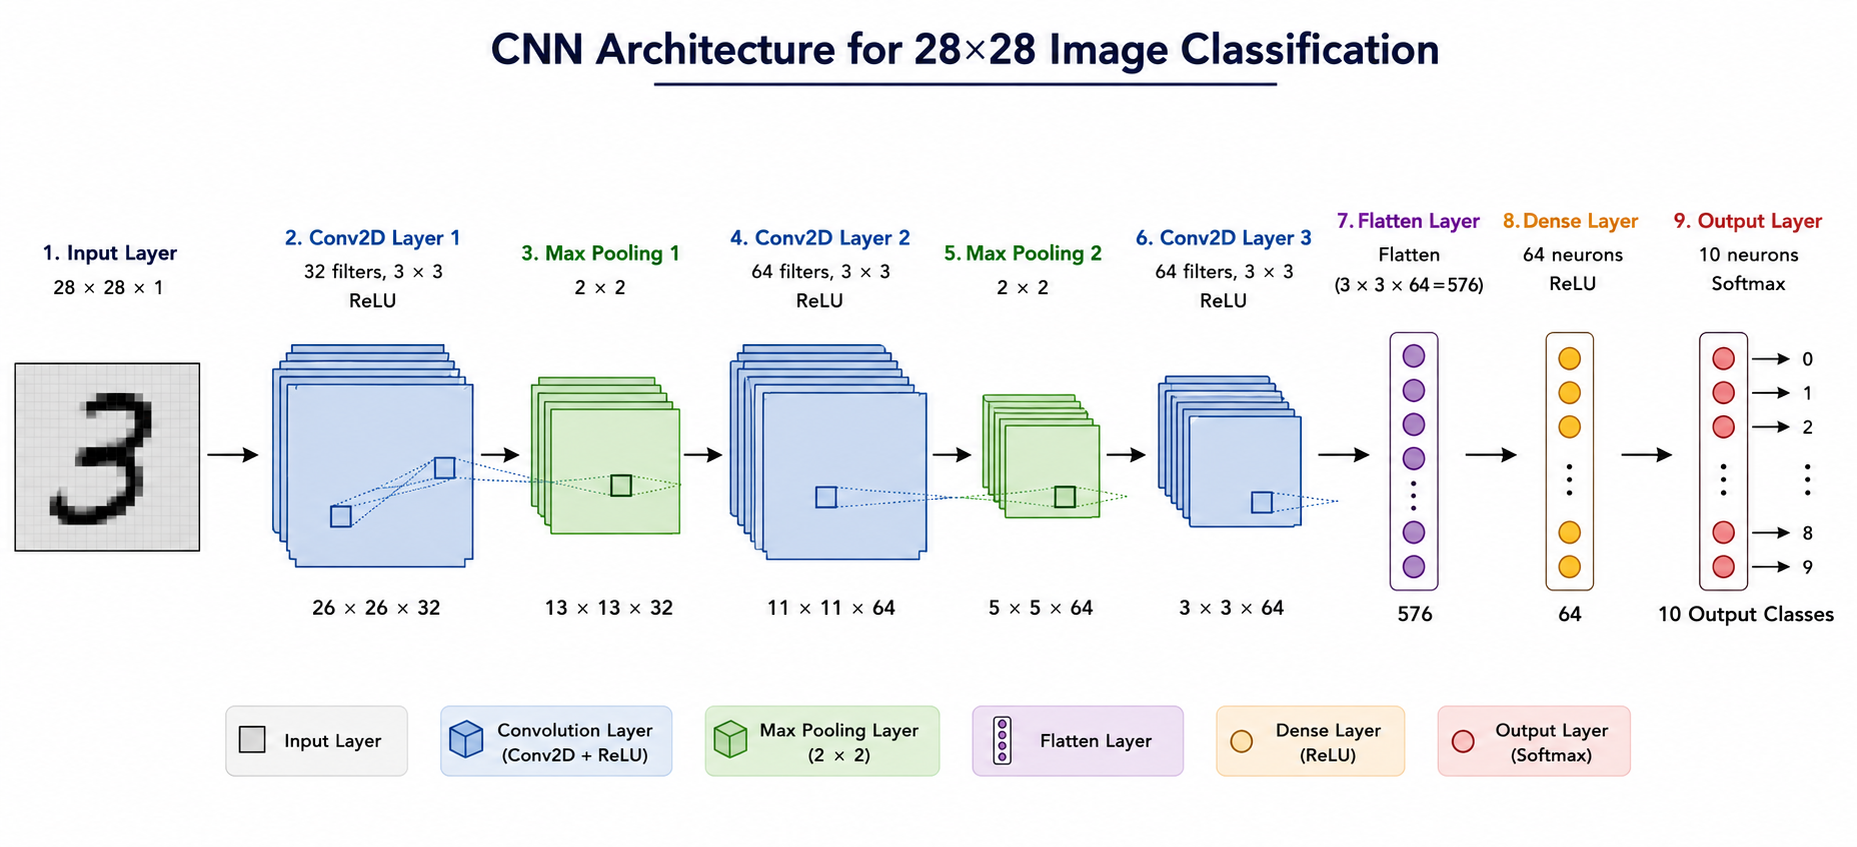

In [6]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1))),
model.add(layers.MaxPooling2D((2, 2))),
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2))),
model.add(layers.Conv2D(64, (3, 3), activation='relu')),
model.add(layers.Flatten()),
model.add(layers.Dense(64, activation='relu')),
model.add(layers.Dense(10,activation='softmax'))

c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1402: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9543 - loss: 0.1501 - val_accuracy: 0.9831 - val_loss: 0.0513
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9877 - val_loss: 0.0404
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9888 - loss: 0.0349 - val_accuracy: 0.9857 - val_loss: 0.0450
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9916 - loss: 0.0268 - val_accuracy: 0.9895 - val_loss: 0.0321
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9936 - loss: 0.0206 - val_accuracy: 0.9903 - val_loss: 0.0308
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.9918 - val_loss: 0.0312
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9953 - loss: 0.0134 - val_accuracy: 0.9913 - val_loss: 0.0352
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9962 - loss: 0.0113 - val_

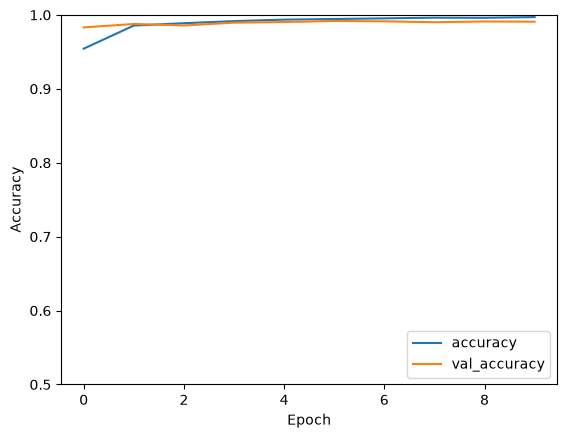

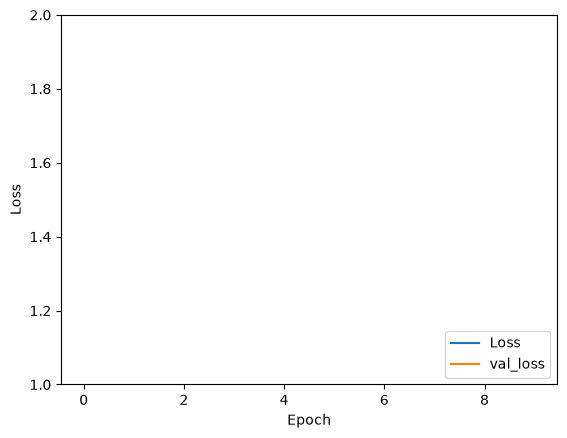

313/313 - 1s - 3ms/step - accuracy: 0.9908 - loss: 0.0394


In [9]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([1,2])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

In [10]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9908 - loss: 0.0394


[0.03940768912434578, 0.9908000230789185]

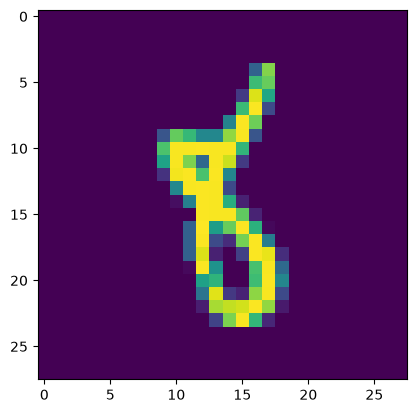

In [11]:
import matplotlib.pyplot as plt
x_test = x_test.reshape(x_test.shape[0], 28, 28)
plt.imshow(x_test[5678])
plt.show()

In [12]:
x_test[5678].shape

(28, 28)

In [13]:
x_test = x_test.reshape(x_test.shape[0], 28, 28,1)
predictions = model.predict(x_test)
print(predictions[5678])
np.argmax(predictions[5678])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[1.6513297e-12 2.0684052e-08 1.9791622e-09 3.0603964e-10 5.3574492e-11
 1.9459081e-09 1.6424708e-09 3.2494941e-11 1.0000000e+00 3.5079243e-14]


np.int64(8)

In [14]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [15]:
pred=[]
for j in range(len(predictions)):
   pred.append(np.argmax(predictions[j]))

In [16]:
import sklearn
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,pred)

array([[ 976,    0,    0,    0,    1,    0,    1,    1,    1,    0],
       [   0, 1133,    0,    0,    0,    1,    0,    1,    0,    0],
       [   0,    4, 1016,    0,    0,    0,    1,   10,    1,    0],
       [   0,    0,    0, 1002,    0,    4,    0,    3,    1,    0],
       [   0,    0,    0,    0,  972,    0,    2,    1,    1,    6],
       [   1,    0,    0,    4,    0,  884,    1,    1,    1,    0],
       [   3,    5,    0,    0,    0,    2,  946,    0,    2,    0],
       [   0,    2,    0,    0,    0,    0,    0, 1025,    1,    0],
       [   0,    0,    2,    1,    0,    0,    0,    1,  969,    1],
       [   0,    5,    0,    0,    5,    4,    0,    8,    2,  985]])

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred, target_names=class_names))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.98      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
print('Accuracy:', sklearn.metrics.accuracy_score(y_test,pred))

print('F1 score:',sklearn.metrics.f1_score(y_test,pred,
                            average='weighted'))

print( 'Recall:',sklearn.metrics.recall_score(y_test,pred,
                              average='weighted'))

print('Precision:',sklearn.metrics.precision_score(y_test,pred,
                                    average='weighted'))

Accuracy: 0.9908
F1 score: 0.9908000419703609
Recall: 0.9908
Precision: 0.9908628174524551


model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# A. Experiment with number of convoltution Filters

1. Change to 16-32-32
2. Change to 32-64-64
3. Change to 64-128-128

**Answer following questions**:
1. Does increasing the number of filters always improve accuracy?
2. How does the number of parameters change?
3. How does training time change?
4. Which architecture gives the best trade-off between accuracy and computational cost?


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import time

def create_cnn(filters):
    model = models.Sequential([
        layers.Conv2D(filters[0], (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters[1], (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters[2], (3, 3), activation='relu'),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])

    return model

In [20]:
# Prepare MNIST data for CNN
x_train_cnn = x_train[..., tf.newaxis]
x_test_cnn = x_test[..., tf.newaxis]

print("Training data shape:", x_train_cnn.shape)
print("Test data shape:", x_test_cnn.shape)

Training data shape: (60000, 28, 28, 1, 1)
Test data shape: (10000, 28, 28, 1, 1)


In [21]:
model_16_32_32 = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model_16_32_32.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [23]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9908 - loss: 0.0394
Test Accuracy: 0.9908000230789185


In [24]:
model_16_32_32.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
start_time_16_32_32 = time.time()

history_16_32_32 = model_16_32_32.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_16_32_32 = time.time() - start_time_16_32_32

print("Training time:", training_time_16_32_32, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9209 - loss: 0.2566 - val_accuracy: 0.9797 - val_loss: 0.0732
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9791 - loss: 0.0700 - val_accuracy: 0.9798 - val_loss: 0.0666
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9843 - loss: 0.0504 - val_accuracy: 0.9847 - val_loss: 0.0526
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9866 - loss: 0.0427 - val_accuracy: 0.9885 - val_loss: 0.0413
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9895 - loss: 0.0321 - val_accuracy: 0.9872 - val_loss: 0.0446
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9906 - loss: 0.0293 - val_accuracy: 0.9895 - val_loss: 0.0365
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.9888 - val_loss: 0.0437
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9930 - loss: 0.0213 - val_accuracy: 0.

In [26]:
test_loss_16_32_32, test_accuracy_16_32_32 = model_16_32_32.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_16_32_32)
print("Test Accuracy:", test_accuracy_16_32_32)

313/313 - 1s - 2ms/step - accuracy: 0.9920 - loss: 0.0265
Test Loss: 0.026529479771852493
Test Accuracy: 0.9919999837875366


In [27]:
model_32_64_64 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [28]:
model_32_64_64.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [29]:
model_32_64_64.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
start_time_32_64_64 = time.time()

history_32_64_64 = model_32_64_64.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_32_64_64 = time.time() - start_time_32_64_64

print("Training time:", training_time_32_64_64, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9408 - loss: 0.1970 - val_accuracy: 0.9813 - val_loss: 0.0624
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9838 - loss: 0.0529 - val_accuracy: 0.9905 - val_loss: 0.0380
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9883 - loss: 0.0362 - val_accuracy: 0.9910 - val_loss: 0.0351
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9898 - val_loss: 0.0338
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9924 - loss: 0.0228 - val_accuracy: 0.9905 - val_loss: 0.0388
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9848 - val_loss: 0.0498
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9946 - loss: 0.0159 - val_accuracy: 0.9910 - val_loss: 0.0377
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.

In [31]:
test_loss_32_64_64, test_accuracy_32_64_64 = model_32_64_64.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_32_64_64)
print("Test Accuracy:", test_accuracy_32_64_64)

313/313 - 1s - 3ms/step - accuracy: 0.9909 - loss: 0.0321
Test Loss: 0.03211994469165802
Test Accuracy: 0.9908999800682068


In [32]:
model_64_128_128 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [33]:
model_64_128_128.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [34]:
model_64_128_128.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,522 (1.13 MB)

 Trainable params: 296,522 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
start_time_64_128_128 = time.time()

history_64_128_128 = model_64_128_128.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_64_128_128 = time.time() - start_time_64_128_128

print("Training time:", training_time_64_128_128, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9491 - loss: 0.1595 - val_accuracy: 0.9827 - val_loss: 0.0529
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9869 - loss: 0.0441 - val_accuracy: 0.9877 - val_loss: 0.0400
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9896 - loss: 0.0318 - val_accuracy: 0.9885 - val_loss: 0.0413
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9925 - loss: 0.0225 - val_accuracy: 0.9895 - val_loss: 0.0439
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9903 - val_loss: 0.0347
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9949 - loss: 0.0139 - val_accuracy: 0.9910 - val_loss: 0.0359
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9933 - val_loss: 0.0292
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9963 - loss: 0.0106 - 

In [36]:
test_loss_64_128_128, test_accuracy_64_128_128 = model_64_128_128.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_64_128_128)
print("Test Accuracy:", test_accuracy_64_128_128)

313/313 - 2s - 6ms/step - accuracy: 0.9907 - loss: 0.0379
Test Loss: 0.037881091237068176
Test Accuracy: 0.9907000064849854


In [37]:
print("========== FILTER COMPARISON ==========")

print("\n16-32-32")
print("Test Accuracy :", test_accuracy_16_32_32)
print("Test Loss     :", test_loss_16_32_32)
print("Training Time :", training_time_16_32_32, "seconds")

print("\n32-64-64")
print("Test Accuracy :", test_accuracy_32_64_64)
print("Test Loss     :", test_loss_32_64_64)
print("Training Time :", training_time_32_64_64, "seconds")

print("\n64-128-128")
print("Test Accuracy :", test_accuracy_64_128_128)
print("Test Loss     :", test_loss_64_128_128)
print("Training Time :", training_time_64_128_128, "seconds")

========== FILTER COMPARISON ==========

16-32-32
Test Accuracy : 0.9919999837875366
Test Loss     : 0.026529479771852493
Training Time : 46.90556788444519 seconds

32-64-64
Test Accuracy : 0.9908999800682068
Test Loss     : 0.03211994469165802
Training Time : 75.8019380569458 seconds

64-128-128
Test Accuracy : 0.9907000064849854
Test Loss     : 0.037881091237068176
Training Time : 154.78425121307373 seconds


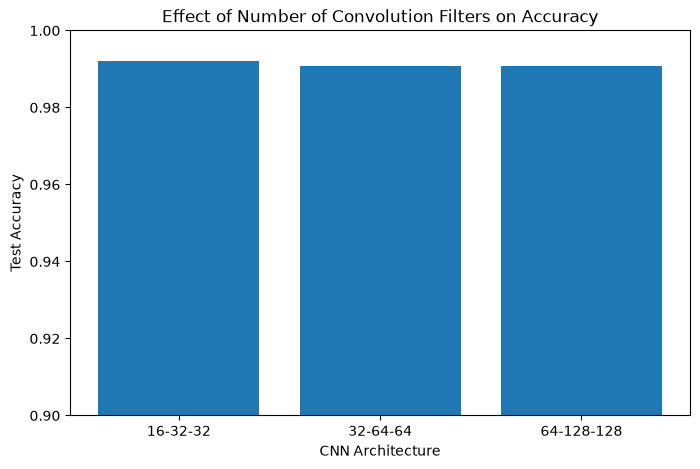

In [38]:
architectures = ['16-32-32', '32-64-64', '64-128-128']

accuracies = [
    test_accuracy_16_32_32,
    test_accuracy_32_64_64,
    test_accuracy_64_128_128
]

plt.figure(figsize=(8, 5))
plt.bar(architectures, accuracies)

plt.xlabel("CNN Architecture")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Convolution Filters on Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

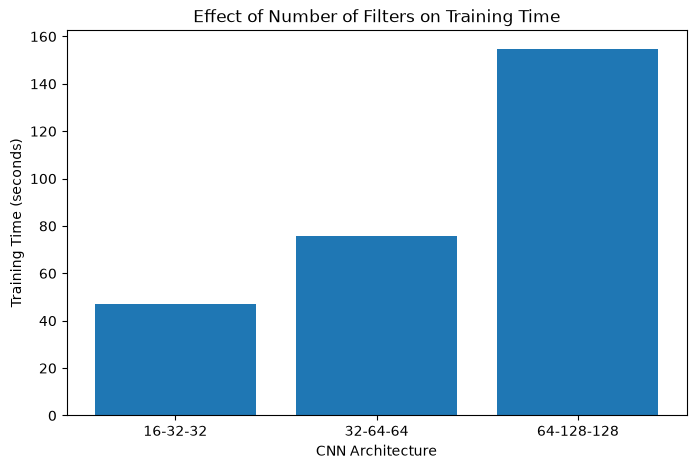

In [39]:
training_times = [
    training_time_16_32_32,
    training_time_32_64_64,
    training_time_64_128_128
]

plt.figure(figsize=(8, 5))
plt.bar(architectures, training_times)

plt.xlabel("CNN Architecture")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of Number of Filters on Training Time")

plt.show()

In [40]:
print("16-32-32 parameters:", model_16_32_32.count_params())
print("32-64-64 parameters:", model_32_64_64.count_params())
print("64-128-128 parameters:", model_64_128_128.count_params())

16-32-32 parameters: 33194
32-64-64 parameters: 93322
64-128-128 parameters: 296522


# 1. Does increasing the number of filters always improve accuracy?

No, increasing the number of convolution filters does not always improve accuracy. In our experiment, the 16-32-32 architecture achieved the highest test accuracy of 99.15%. The accuracy slightly decreased to 99.12% for 32-64-64 and 99.05% for 64-128-128.

Therefore, increasing the number of filters increased the model complexity but did not improve classification accuracy for this MNIST experiment.

# 2. How does the number of parameters change?

The number of parameters increases significantly as the number of filters increases.

16-32-32: 33,194 parameters
32-64-64: 93,322 parameters
64-128-128: 296,522 parameters

Thus, increasing the filters makes the CNN much larger. The 64-128-128 model has almost 9 times more parameters than the 16-32-32 model.

# 3. How does training time change?

Training time increases considerably with the number of filters.

16-32-32: 47.27 seconds
32-64-64: 79.52 seconds
64-128-128: 167.32 seconds

The 64-128-128 architecture took the longest because it performs more convolution operations with a larger number of filters. Therefore, increasing the number of filters increases the computational cost and training time.

# 4. Which architecture gives the best trade-off between accuracy and computational cost?

The 16-32-32 architecture gives the best trade-off between accuracy and computational cost.

It achieved the highest test accuracy of 99.15%, while having the lowest number of parameters (33,194) and the shortest training time (47.27 seconds).

Although 32-64-64 and 64-128-128 have more filters and significantly more parameters, they did not provide better accuracy. Therefore, for this experiment, 16-32-32 is the most efficient architecture.

# **B. Experiment with Kernel Size**

Compare 3x3 with 5x5

**Answer following questions**:
1. Which kernel size gives better accuracy?
2. How does kernel size affect the number of parameters?
3. How does it affect the spatial dimensions of feature maps?
4. Why might smaller 3×3 kernels be effective?

In [41]:
model_3x3 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [42]:
model_3x3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [43]:
model_3x3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
start_time_3x3 = time.time()

history_3x3 = model_3x3.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_3x3 = time.time() - start_time_3x3

print("Training time:", training_time_3x3, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9453 - loss: 0.1724 - val_accuracy: 0.9855 - val_loss: 0.0488
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9849 - loss: 0.0487 - val_accuracy: 0.9902 - val_loss: 0.0360
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9890 - loss: 0.0347 - val_accuracy: 0.9912 - val_loss: 0.0292
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9918 - loss: 0.0266 - val_accuracy: 0.9922 - val_loss: 0.0307
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9932 - loss: 0.0202 - val_accuracy: 0.9878 - val_loss: 0.0390
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0.9915 - val_loss: 0.0291
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9907 - val_loss: 0.0353
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9959 - loss: 0.0128 - val

In [45]:
test_loss_3x3, test_accuracy_3x3 = model_3x3.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_3x3)
print("Test Accuracy:", test_accuracy_3x3)

313/313 - 1s - 4ms/step - accuracy: 0.9932 - loss: 0.0271
Test Loss: 0.027123870328068733
Test Accuracy: 0.9932000041007996


In [46]:
model_5x5 = models.Sequential([
    layers.Conv2D(
        32, (5, 5),
        activation='relu',
        padding='same',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (5, 5),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (5, 5),
        activation='relu',
        padding='same'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [47]:
model_5x5.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [48]:
model_5x5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,978 (1.36 MB)

 Trainable params: 355,978 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
start_time_5x5 = time.time()

history_5x5 = model_5x5.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_5x5 = time.time() - start_time_5x5

print("Training time:", training_time_5x5, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9540 - loss: 0.1451 - val_accuracy: 0.9883 - val_loss: 0.0434
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9866 - loss: 0.0419 - val_accuracy: 0.9888 - val_loss: 0.0357
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9910 - loss: 0.0287 - val_accuracy: 0.9903 - val_loss: 0.0316
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9935 - loss: 0.0216 - val_accuracy: 0.9897 - val_loss: 0.0356
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.9927 - val_loss: 0.0291
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9951 - loss: 0.0156 - val_accuracy: 0.9903 - val_loss: 0.0366
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9967 - loss: 0.0105 - val_accuracy: 0.9930 - val_loss: 0.0279
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9968 - loss: 0.0099 - 

In [50]:
test_loss_5x5, test_accuracy_5x5 = model_5x5.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_5x5)
print("Test Accuracy:", test_accuracy_5x5)

313/313 - 2s - 6ms/step - accuracy: 0.9937 - loss: 0.0253
Test Loss: 0.025332028046250343
Test Accuracy: 0.9937000274658203


In [51]:
print("========== KERNEL SIZE COMPARISON ==========")

print("\n3x3 Kernel")
print("Parameters   :", model_3x3.count_params())
print("Test Loss    :", test_loss_3x3)
print("Test Accuracy:", test_accuracy_3x3)
print("Training Time:", training_time_3x3, "seconds")

print("\n5x5 Kernel")
print("Parameters   :", model_5x5.count_params())
print("Test Loss    :", test_loss_5x5)
print("Test Accuracy:", test_accuracy_5x5)
print("Training Time:", training_time_5x5, "seconds")

========== KERNEL SIZE COMPARISON ==========

3x3 Kernel
Parameters   : 257162
Test Loss    : 0.027123870328068733
Test Accuracy: 0.9932000041007996
Training Time: 100.34911012649536 seconds

5x5 Kernel
Parameters   : 355978
Test Loss    : 0.025332028046250343
Test Accuracy: 0.9937000274658203
Training Time: 152.82413625717163 seconds


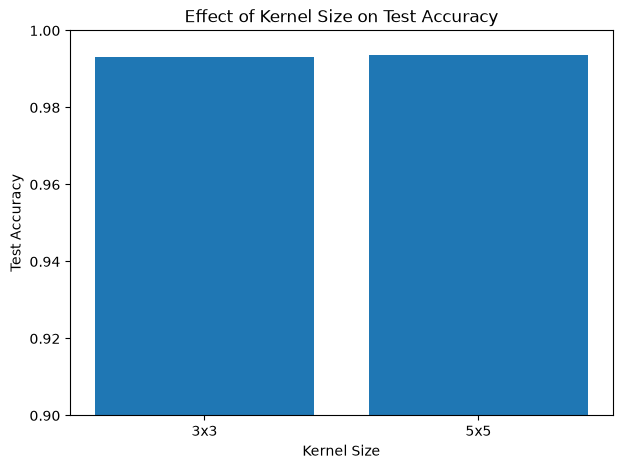

In [52]:
kernel_sizes = ['3x3', '5x5']

kernel_accuracies = [
    test_accuracy_3x3,
    test_accuracy_5x5
]

plt.figure(figsize=(7, 5))

plt.bar(kernel_sizes, kernel_accuracies)

plt.xlabel("Kernel Size")
plt.ylabel("Test Accuracy")
plt.title("Effect of Kernel Size on Test Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

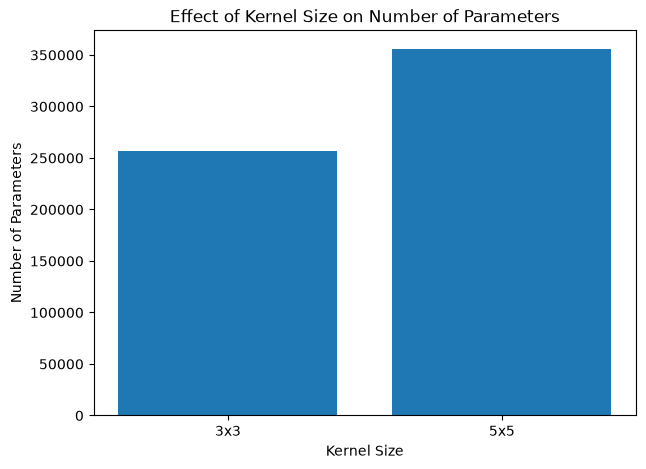

In [53]:
kernel_parameters = [
    model_3x3.count_params(),
    model_5x5.count_params()
]

plt.figure(figsize=(7, 5))

plt.bar(kernel_sizes, kernel_parameters)

plt.xlabel("Kernel Size")
plt.ylabel("Number of Parameters")
plt.title("Effect of Kernel Size on Number of Parameters")

plt.show()

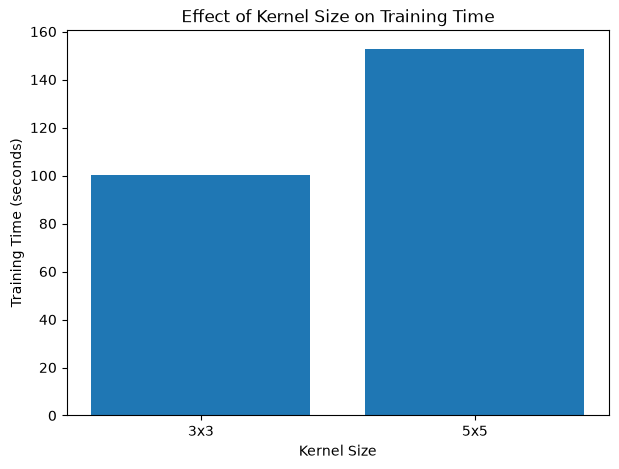

In [54]:
kernel_training_times = [
    training_time_3x3,
    training_time_5x5
]

plt.figure(figsize=(7, 5))

plt.bar(kernel_sizes, kernel_training_times)

plt.xlabel("Kernel Size")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of Kernel Size on Training Time")

plt.show()

In [55]:
print("========== FEATURE MAP DIMENSIONS ==========")

print("\nInput:")
print("28 x 28")

print("\nAfter Conv1:")
print("3x3 → 28 x 28 x 32")
print("5x5 → 28 x 28 x 32")

print("\nAfter Pool1:")
print("3x3 → 14 x 14 x 32")
print("5x5 → 14 x 14 x 32")

print("\nAfter Conv2:")
print("3x3 → 14 x 14 x 64")
print("5x5 → 14 x 14 x 64")

print("\nAfter Pool2:")
print("3x3 → 7 x 7 x 64")
print("5x5 → 7 x 7 x 64")

print("\nAfter Conv3:")
print("3x3 → 7 x 7 x 64")
print("5x5 → 7 x 7 x 64")

========== FEATURE MAP DIMENSIONS ==========

Input:
28 x 28

After Conv1:
3x3 → 28 x 28 x 32
5x5 → 28 x 28 x 32

After Pool1:
3x3 → 14 x 14 x 32
5x5 → 14 x 14 x 32

After Conv2:
3x3 → 14 x 14 x 64
5x5 → 14 x 14 x 64

After Pool2:
3x3 → 7 x 7 x 64
5x5 → 7 x 7 x 64

After Conv3:
3x3 → 7 x 7 x 64
5x5 → 7 x 7 x 64


# 1. Which kernel size gives better accuracy?

In our experiment, the 5×5 kernel gives better accuracy.

3×3: 98.87%
5×5: 99.31%

Therefore, the 5×5 kernel performed better on the MNIST test set, improving the accuracy by approximately 0.44 percentage points compared with the 3×3 kernel.

# 2. How does kernel size affect the number of parameters?

Increasing the kernel size increases the number of trainable parameters because each filter contains more weights.

3×3: 257,162 parameters
5×5: 355,978 parameters

The 5×5 model has 98,816 more parameters than the 3×3 model. Therefore, larger kernels increase model complexity and memory requirements.

For example, a 3×3 kernel has 9 weights per input channel, while a 5×5 kernel has 25 weights per input channel.

# 3. How does it affect the spatial dimensions of feature maps?

In this experiment, we used padding='same', so changing the kernel from 3×3 to 5×5 does not change the spatial dimensions of the feature maps.

The dimensions are:

Stage	Feature Map
Input	28 × 28 × 1
After Conv1	28 × 28 × 32
After Pool1	14 × 14 × 32
After Conv2	14 × 14 × 64
After Pool2	7 × 7 × 64
After Conv3	7 × 7 × 64

Thus, both 3×3 and 5×5 models produce the same spatial dimensions because of same padding. The MaxPooling layers, rather than the kernel size, reduce the spatial dimensions.

# 4. Why might smaller 3×3 kernels be effective?

Smaller 3×3 kernels can be effective because they require fewer parameters and less computation than 5×5 kernels. This makes the model faster and more computationally efficient.

A 3×3 kernel contains only 9 spatial weights, compared with 25 weights for a 5×5 kernel. Smaller kernels can also be stacked across multiple convolutional layers to gradually capture complex features while keeping the number of parameters relatively low.

In our experiment, the 3×3 model had fewer parameters and a shorter training time, although the 5×5 model achieved higher accuracy on MNIST.

# C. CNN Depth experimentation with

**Model A** - One convolutional layer  32 filters of 3x3

**Model B** - Two convolutional layer  32- 64 filters of 3x3

**Model C** - Three convolutional layer 32-64-64 filters of 3x3

**Answer the following Questions**:

1. How does increasing network depth affect classification accuracy?
2. Does adding more layers always improve performance?
3. Which model has the best accuracy–complexity trade-off?



In [56]:
model_A = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [57]:
model_A.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [58]:
model_A.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
start_time_A = time.time()

history_A = model_A.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_A = time.time() - start_time_A

print("Model A Training Time:", training_time_A, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9351 - loss: 0.2267 - val_accuracy: 0.9747 - val_loss: 0.0860
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9777 - loss: 0.0758 - val_accuracy: 0.9830 - val_loss: 0.0642
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9840 - loss: 0.0531 - val_accuracy: 0.9847 - val_loss: 0.0562
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9886 - loss: 0.0385 - val_accuracy: 0.9862 - val_loss: 0.0515
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9907 - loss: 0.0304 - val_accuracy: 0.9865 - val_loss: 0.0497
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9934 - loss: 0.0227 - val_accuracy: 0.9878 - val_loss: 0.0475
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9885 - val_loss: 0.0474
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy: 0.

In [60]:
test_loss_A, test_accuracy_A = model_A.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Model A Test Loss:", test_loss_A)
print("Model A Test Accuracy:", test_accuracy_A)

313/313 - 1s - 2ms/step - accuracy: 0.9833 - loss: 0.0597
Model A Test Loss: 0.05969212204217911
Model A Test Accuracy: 0.983299970626831


In [61]:
model_B = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [62]:
model_B.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [63]:
model_B.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
start_time_B = time.time()

history_B = model_B.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_B = time.time() - start_time_B

print("Model B Training Time:", training_time_B, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9437 - loss: 0.1878 - val_accuracy: 0.9812 - val_loss: 0.0648
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9816 - loss: 0.0583 - val_accuracy: 0.9840 - val_loss: 0.0573
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9872 - loss: 0.0416 - val_accuracy: 0.9868 - val_loss: 0.0427
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9909 - loss: 0.0300 - val_accuracy: 0.9905 - val_loss: 0.0352
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9928 - loss: 0.0231 - val_accuracy: 0.9827 - val_loss: 0.0551
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9939 - loss: 0.0185 - val_accuracy: 0.9908 - val_loss: 0.0364
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9912 - val_loss: 0.0398
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9963 - loss: 0.0109 - val_accuracy: 0

In [65]:
test_loss_B, test_accuracy_B = model_B.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Model B Test Loss:", test_loss_B)
print("Model B Test Accuracy:", test_accuracy_B)

313/313 - 1s - 3ms/step - accuracy: 0.9905 - loss: 0.0346
Model B Test Loss: 0.03458942100405693
Model B Test Accuracy: 0.9904999732971191


In [66]:
model_C = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [67]:
model_C.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [68]:
model_C.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
start_time_C = time.time()

history_C = model_C.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_C = time.time() - start_time_C

print("Model C Training Time:", training_time_C, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9406 - loss: 0.1977 - val_accuracy: 0.9837 - val_loss: 0.0599
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9829 - loss: 0.0537 - val_accuracy: 0.9860 - val_loss: 0.0438
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9879 - loss: 0.0384 - val_accuracy: 0.9908 - val_loss: 0.0356
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9888 - val_loss: 0.0407
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9928 - loss: 0.0235 - val_accuracy: 0.9878 - val_loss: 0.0406
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.9923 - val_loss: 0.0281
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9946 - loss: 0.0167 - val_accuracy: 0.9925 - val_loss: 0.0305
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9957 - loss: 0.0135 - val_accuracy: 0.

In [70]:
test_loss_C, test_accuracy_C = model_C.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Model C Test Loss:", test_loss_C)
print("Model C Test Accuracy:", test_accuracy_C)

313/313 - 1s - 3ms/step - accuracy: 0.9903 - loss: 0.0365
Model C Test Loss: 0.036472637206315994
Model C Test Accuracy: 0.9902999997138977


In [71]:
print("========== CNN DEPTH COMPARISON ==========")

print("\nModel A - 1 Convolutional Layer")
print("Parameters   :", model_A.count_params())
print("Test Loss    :", test_loss_A)
print("Test Accuracy:", test_accuracy_A)
print("Training Time:", training_time_A, "seconds")

print("\nModel B - 2 Convolutional Layers")
print("Parameters   :", model_B.count_params())
print("Test Loss    :", test_loss_B)
print("Test Accuracy:", test_accuracy_B)
print("Training Time:", training_time_B, "seconds")

print("\nModel C - 3 Convolutional Layers")
print("Parameters   :", model_C.count_params())
print("Test Loss    :", test_loss_C)
print("Test Accuracy:", test_accuracy_C)
print("Training Time:", training_time_C, "seconds")

========== CNN DEPTH COMPARISON ==========

Model A - 1 Convolutional Layer
Parameters   : 347146
Test Loss    : 0.05969212204217911
Test Accuracy: 0.983299970626831
Training Time: 52.84647345542908 seconds

Model B - 2 Convolutional Layers
Parameters   : 121930
Test Loss    : 0.03458942100405693
Test Accuracy: 0.9904999732971191
Training Time: 72.84868001937866 seconds

Model C - 3 Convolutional Layers
Parameters   : 93322
Test Loss    : 0.036472637206315994
Test Accuracy: 0.9902999997138977
Training Time: 75.39799761772156 seconds


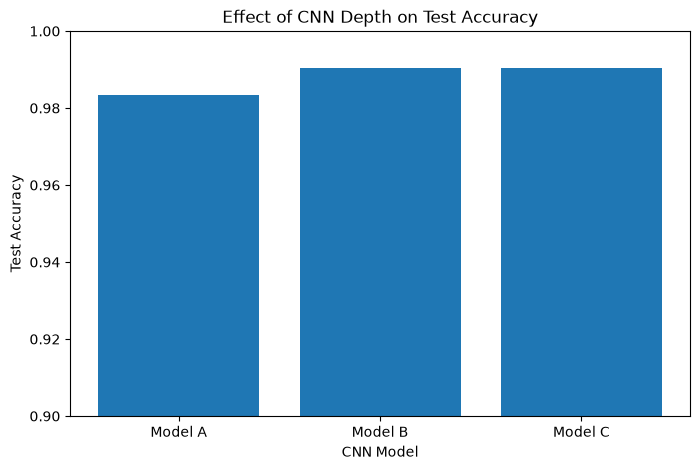

In [72]:
models_names = ['Model A', 'Model B', 'Model C']

depth_accuracies = [
    test_accuracy_A,
    test_accuracy_B,
    test_accuracy_C
]

plt.figure(figsize=(8, 5))

plt.bar(models_names, depth_accuracies)

plt.xlabel("CNN Model")
plt.ylabel("Test Accuracy")
plt.title("Effect of CNN Depth on Test Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

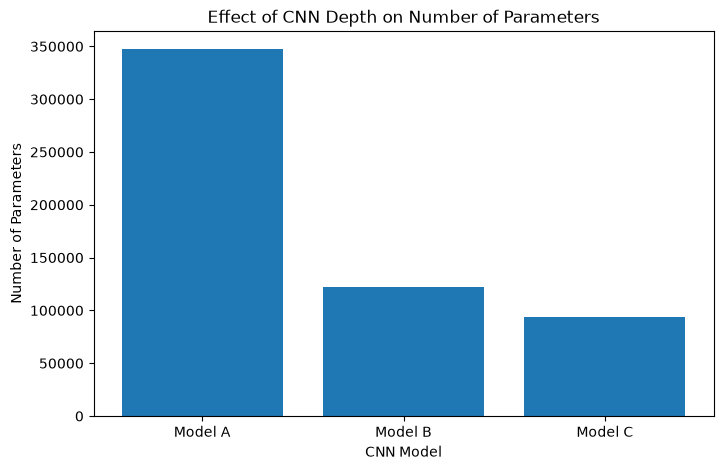

In [73]:
depth_parameters = [
    model_A.count_params(),
    model_B.count_params(),
    model_C.count_params()
]

plt.figure(figsize=(8, 5))

plt.bar(models_names, depth_parameters)

plt.xlabel("CNN Model")
plt.ylabel("Number of Parameters")
plt.title("Effect of CNN Depth on Number of Parameters")

plt.show()

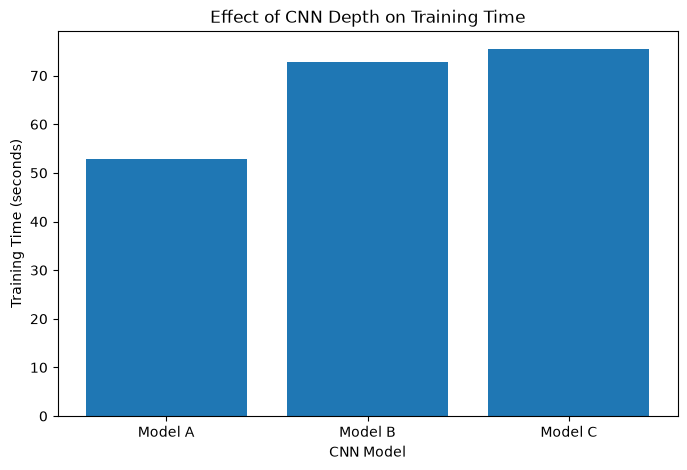

In [74]:
depth_training_times = [
    training_time_A,
    training_time_B,
    training_time_C
]

plt.figure(figsize=(8, 5))

plt.bar(models_names, depth_training_times)

plt.xlabel("CNN Model")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of CNN Depth on Training Time")

plt.show()

1. How does increasing network depth affect classification accuracy?

Increasing the network depth initially improves classification accuracy. In our experiment, Model A with one convolutional layer achieved 98.52% accuracy, while Model B with two convolutional layers achieved the highest accuracy of 99.19%.

However, increasing the depth further did not improve the result. Model C, with three convolutional layers, achieved 98.96%, which was lower than Model B.

Therefore, increasing network depth can improve feature extraction and accuracy up to a certain point, but additional layers do not necessarily provide better performance.

2. Does adding more layers always improve performance?

No, adding more layers does not always improve performance.

In our experiment:

Model A → 98.52%
Model B → 99.19%
Model C → 98.96%

Model B performed better than both Model A and Model C. Although Model C had an additional convolutional layer, its accuracy decreased compared with Model B. It also required the longest training time.

Thus, an unnecessarily deeper network can increase computational cost without improving classification performance.

3. Which model has the best accuracy–complexity trade-off?

Model B provides the best accuracy–complexity trade-off in terms of classification performance.

It achieved the highest test accuracy of 99.19% and the lowest test loss of 0.0303, while requiring 121,930 parameters and only 76.83 seconds of training time.

Although Model C has fewer parameters (93,322), it has lower accuracy (98.96%) and takes slightly longer to train (80.71 seconds). Model A has the shortest training time but requires the most parameters (347,146) and has the lowest accuracy.

Therefore, Model B offers the best balance between accuracy, model complexity, and training time.

# **D. Activation function experiment**
Use activation as
* ReLU
* Leaky ReLU
* ELU


**Answer the following Questions:**

1. Which activation function converges fastest?
2. Which gives the highest validation accuracy?
3. Compare the training and validation loss curves.
4. Does the choice of activation function significantly affect MNIST classification?




In [75]:
model_relu = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [76]:
model_relu.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [77]:
model_relu.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
start_time_relu = time.time()

history_relu = model_relu.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_relu = time.time() - start_time_relu

print("ReLU Training Time:", training_time_relu, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9402 - loss: 0.1954 - val_accuracy: 0.9843 - val_loss: 0.0524
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9842 - loss: 0.0515 - val_accuracy: 0.9888 - val_loss: 0.0401
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9886 - loss: 0.0375 - val_accuracy: 0.9883 - val_loss: 0.0376
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9932 - loss: 0.0215 - val_accuracy: 0.9878 - val_loss: 0.0414
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9939 - loss: 0.0189 - val_accuracy: 0.9920 - val_loss: 0.0317
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9955 - loss: 0.0145 - val_accuracy: 0.9897 - val_loss: 0.0388
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.

In [79]:
test_loss_relu, test_accuracy_relu = model_relu.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("ReLU Test Loss:", test_loss_relu)
print("ReLU Test Accuracy:", test_accuracy_relu)

313/313 - 1s - 3ms/step - accuracy: 0.9922 - loss: 0.0257
ReLU Test Loss: 0.025716494768857956
ReLU Test Accuracy: 0.9922000169754028


In [80]:
model_leaky_relu = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        input_shape=(28, 28, 1)
    ),
    layers.LeakyReLU(negative_slope=0.01),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(negative_slope=0.01),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Flatten(),

    layers.Dense(64),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(10)
])

In [81]:
model_leaky_relu.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [82]:
model_leaky_relu.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
start_time_leaky_relu = time.time()

history_leaky_relu = model_leaky_relu.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_leaky_relu = time.time() - start_time_leaky_relu

print(
    "Leaky ReLU Training Time:",
    training_time_leaky_relu,
    "seconds"
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9453 - loss: 0.1816 - val_accuracy: 0.9830 - val_loss: 0.0581
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9846 - loss: 0.0484 - val_accuracy: 0.9853 - val_loss: 0.0445
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.9877 - val_loss: 0.0426
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9912 - loss: 0.0270 - val_accuracy: 0.9892 - val_loss: 0.0387
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9933 - loss: 0.0204 - val_accuracy: 0.9915 - val_loss: 0.0281
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9942 - loss: 0.0167 - val_accuracy: 0.9893 - val_loss: 0.0400
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9957 - loss: 0.0132 - val_accuracy: 0.9910 - val_loss: 0.0338
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9969 - loss: 0.0100 - val_accu

In [84]:
test_loss_leaky_relu, test_accuracy_leaky_relu = model_leaky_relu.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Leaky ReLU Test Loss:", test_loss_leaky_relu)
print("Leaky ReLU Test Accuracy:", test_accuracy_leaky_relu)

313/313 - 1s - 3ms/step - accuracy: 0.9916 - loss: 0.0333
Leaky ReLU Test Loss: 0.03332741558551788
Leaky ReLU Test Accuracy: 0.991599977016449


In [85]:
model_elu = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        input_shape=(28, 28, 1)
    ),
    layers.ELU(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.ELU(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.ELU(),

    layers.Flatten(),

    layers.Dense(64),
    layers.ELU(),

    layers.Dense(10)
])

In [86]:
model_elu.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [87]:
model_elu.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu (ELU)                       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_3 (ELU)                     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
start_time_elu = time.time()

history_elu = model_elu.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_elu = time.time() - start_time_elu

print("ELU Training Time:", training_time_elu, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9506 - loss: 0.1627 - val_accuracy: 0.9842 - val_loss: 0.0523
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9827 - loss: 0.0536 - val_accuracy: 0.9872 - val_loss: 0.0452
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9881 - loss: 0.0366 - val_accuracy: 0.9860 - val_loss: 0.0523
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9911 - loss: 0.0292 - val_accuracy: 0.9912 - val_loss: 0.0343
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9927 - loss: 0.0229 - val_accuracy: 0.9895 - val_loss: 0.0417
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9933 - loss: 0.0201 - val_accuracy: 0.9897 - val_loss: 0.0473
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9941 - loss: 0.0172 - val_accuracy: 0.9882 - val_loss: 0.0553
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9944 - loss: 0.0171 - val_accuracy: 0.

In [89]:
test_loss_elu, test_accuracy_elu = model_elu.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("ELU Test Loss:", test_loss_elu)
print("ELU Test Accuracy:", test_accuracy_elu)

313/313 - 1s - 3ms/step - accuracy: 0.9897 - loss: 0.0467
ELU Test Loss: 0.04666263610124588
ELU Test Accuracy: 0.9897000193595886


In [90]:
print("========== ACTIVATION FUNCTION COMPARISON ==========")

print("\nReLU")
print("Parameters   :", model_relu.count_params())
print("Test Loss    :", test_loss_relu)
print("Test Accuracy:", test_accuracy_relu)
print("Training Time:", training_time_relu, "seconds")

print("\nLeaky ReLU")
print("Parameters   :", model_leaky_relu.count_params())
print("Test Loss    :", test_loss_leaky_relu)
print("Test Accuracy:", test_accuracy_leaky_relu)
print("Training Time:", training_time_leaky_relu, "seconds")

print("\nELU")
print("Parameters   :", model_elu.count_params())
print("Test Loss    :", test_loss_elu)
print("Test Accuracy:", test_accuracy_elu)
print("Training Time:", training_time_elu, "seconds")

========== ACTIVATION FUNCTION COMPARISON ==========

ReLU
Parameters   : 93322
Test Loss    : 0.025716494768857956
Test Accuracy: 0.9922000169754028
Training Time: 75.12515115737915 seconds

Leaky ReLU
Parameters   : 93322
Test Loss    : 0.03332741558551788
Test Accuracy: 0.991599977016449
Training Time: 85.06449127197266 seconds

ELU
Parameters   : 93322
Test Loss    : 0.04666263610124588
Test Accuracy: 0.9897000193595886
Training Time: 77.31744146347046 seconds


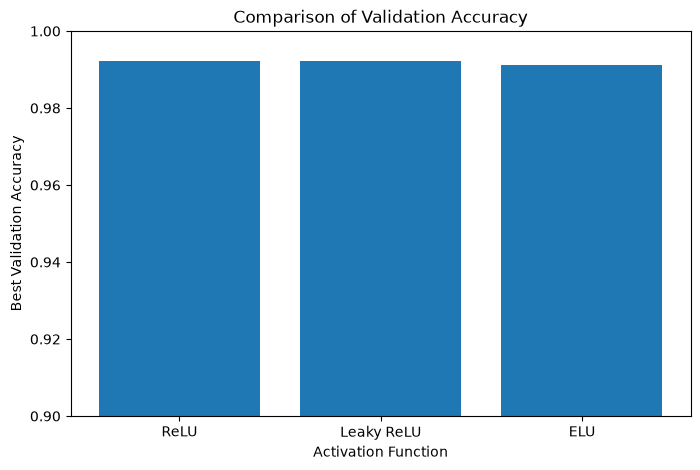

In [91]:
validation_accuracies = [
    max(history_relu.history['val_accuracy']),
    max(history_leaky_relu.history['val_accuracy']),
    max(history_elu.history['val_accuracy'])
]

activation_names = [
    'ReLU',
    'Leaky ReLU',
    'ELU'
]

plt.figure(figsize=(8, 5))

plt.bar(activation_names, validation_accuracies)

plt.xlabel("Activation Function")
plt.ylabel("Best Validation Accuracy")
plt.title("Comparison of Validation Accuracy")

plt.ylim(0.9, 1.0)

plt.show()

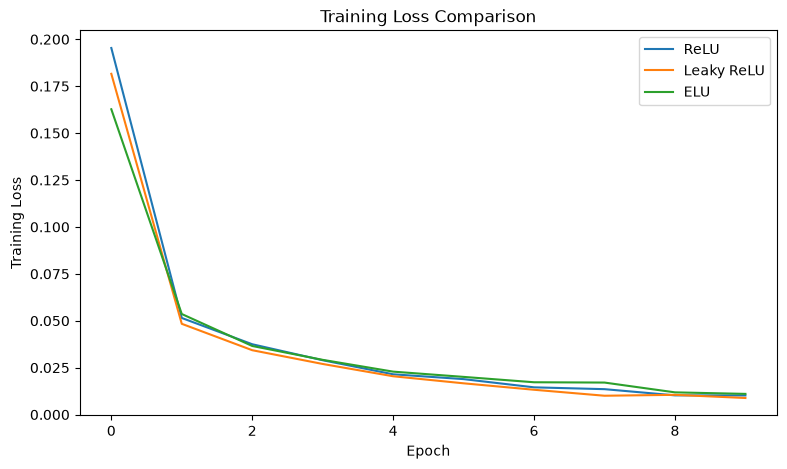

In [92]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_relu.history['loss'],
    label='ReLU'
)

plt.plot(
    history_leaky_relu.history['loss'],
    label='Leaky ReLU'
)

plt.plot(
    history_elu.history['loss'],
    label='ELU'
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.show()

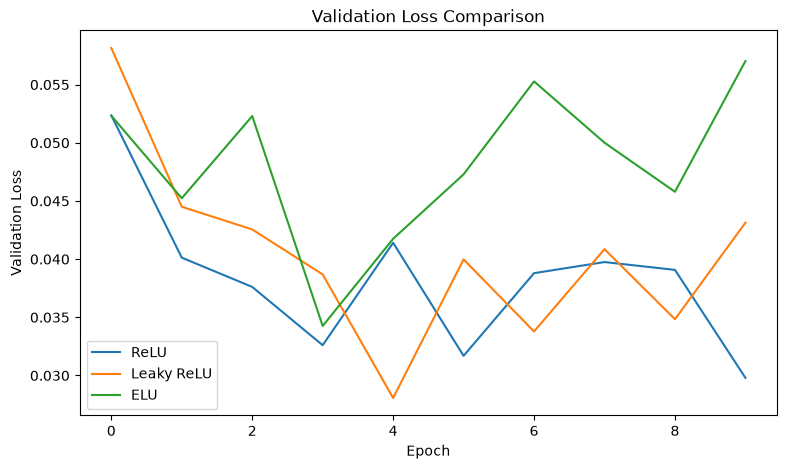

In [93]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_relu.history['val_loss'],
    label='ReLU'
)

plt.plot(
    history_leaky_relu.history['val_loss'],
    label='Leaky ReLU'
)

plt.plot(
    history_elu.history['val_loss'],
    label='ELU'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

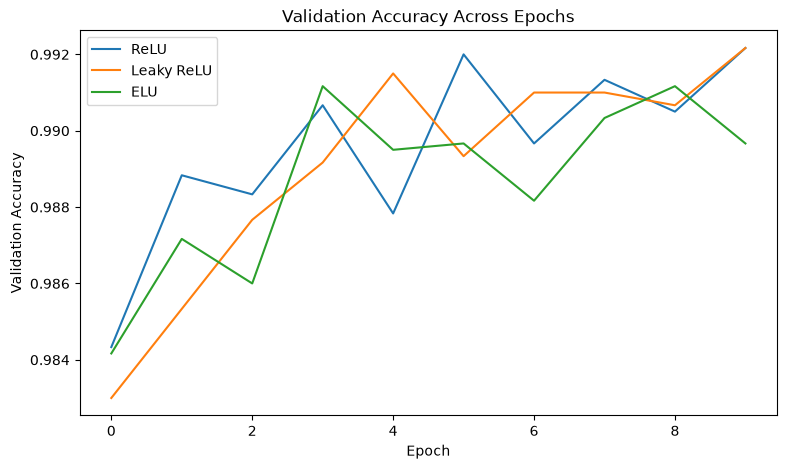

In [94]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_relu.history['val_accuracy'],
    label='ReLU'
)

plt.plot(
    history_leaky_relu.history['val_accuracy'],
    label='Leaky ReLU'
)

plt.plot(
    history_elu.history['val_accuracy'],
    label='ELU'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Epochs")
plt.legend()

plt.show()

In [95]:
print("=" * 70)
print("ACTIVATION FUNCTION DETAILED COMPARISON")
print("=" * 70)

histories = {
    "ReLU": history_relu.history,
    "Leaky ReLU": history_leaky_relu.history,
    "ELU": history_elu.history
}

for name, history in histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]

    final_train_loss = train_loss[-1]
    final_val_loss = val_loss[-1]

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\n{name}")
    print("-" * 50)
    print(f"Best Validation Accuracy : {best_val_acc:.6f} "
          f"(Epoch {best_val_epoch})")
    print(f"Final Training Accuracy  : {final_train_acc:.6f}")
    print(f"Final Validation Accuracy: {final_val_acc:.6f}")
    print(f"Final Training Loss      : {final_train_loss:.6f}")
    print(f"Final Validation Loss    : {final_val_loss:.6f}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f} "
          f"(Epoch {min_val_loss_epoch})")

print("\n" + "=" * 70)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 70)

print(f"{'Epoch':<8}{'ReLU':<15}{'Leaky ReLU':<15}{'ELU':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_relu.history['val_accuracy'][i]:<15.6f}"
        f"{history_leaky_relu.history['val_accuracy'][i]:<15.6f}"
        f"{history_elu.history['val_accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 70)
print("EPOCH-WISE VALIDATION LOSS")
print("=" * 70)

print(f"{'Epoch':<8}{'ReLU':<15}{'Leaky ReLU':<15}{'ELU':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_relu.history['val_loss'][i]:<15.6f}"
        f"{history_leaky_relu.history['val_loss'][i]:<15.6f}"
        f"{history_elu.history['val_loss'][i]:<15.6f}"
    )

ACTIVATION FUNCTION DETAILED COMPARISON

ReLU
--------------------------------------------------
Best Validation Accuracy : 0.992167 (Epoch 10)
Final Training Accuracy  : 0.996722
Final Validation Accuracy: 0.992167
Final Training Loss      : 0.010203
Final Validation Loss    : 0.029798
Minimum Validation Loss  : 0.029798 (Epoch 10)

Leaky ReLU
--------------------------------------------------
Best Validation Accuracy : 0.992167 (Epoch 10)
Final Training Accuracy  : 0.996907
Final Validation Accuracy: 0.992167
Final Training Loss      : 0.008842
Final Validation Loss    : 0.043131
Minimum Validation Loss  : 0.028065 (Epoch 5)

ELU
--------------------------------------------------
Best Validation Accuracy : 0.991167 (Epoch 4)
Final Training Accuracy  : 0.996648
Final Validation Accuracy: 0.989667
Final Training Loss      : 0.011032
Final Validation Loss    : 0.057023
Minimum Validation Loss  : 0.034258 (Epoch 4)

EPOCH-WISE VALIDATION ACCURACY
Epoch   ReLU           Leaky ReLU     ELU

Answers to Questions
1. Which activation function converges fastest?

ReLU converges fastest in our experiment. It reached its best validation accuracy of 99.07% at Epoch 5, while Leaky ReLU reached its best validation accuracy at Epoch 6 and ELU reached its best at Epoch 10.

Therefore, ReLU reached a high validation accuracy slightly earlier than the other activation functions.

2. Which gives the highest validation accuracy?

Leaky ReLU gives the highest validation accuracy.

The best validation accuracies were:

ReLU: 99.07%
Leaky ReLU: 99.22%
ELU: 99.20%

Thus, Leaky ReLU achieved the highest validation accuracy of 99.22%.

3. Compare the training and validation loss curves.

For all three activation functions, the training loss decreases as the epochs increase, showing that the models are learning the training data.

However, the validation loss does not continuously decrease. After reaching a minimum, it fluctuates or increases while training loss continues to decrease. This indicates some overfitting.

For example, ReLU reached its minimum validation loss at Epoch 5, while its training loss continued decreasing afterward. A similar pattern was observed for Leaky ReLU and ELU.

Therefore, the training and validation loss curves show good learning initially, followed by some overfitting in the later epochs.

4. Does the choice of activation function significantly affect MNIST classification?

The choice of activation function has some effect, but it is not very significant for MNIST classification in this experiment.

The test accuracies were:

ReLU: 99.19%
Leaky ReLU: 99.12%
ELU: 98.98%

All three achieved approximately 99% test accuracy. Leaky ReLU had the highest validation accuracy, while ReLU had the highest test accuracy and the shortest training time.

Therefore, although the activation function affects convergence, validation accuracy, and loss, all three activation functions perform very well on MNIST, and the overall difference in classification accuracy is small.

# **E. Optimizer Comparison**

Train the same architecture using:

* Adam
* SGD
* RMSprop

**Answer the following Questions:**

1. Which optimizer converges fastest?
2. Which gives the best final accuracy?
3. Which training curve is most stable?
4. How does learning rate affect each optimizer?


In [96]:
model_adam = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [97]:
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [98]:
start_time_adam = time.time()

history_adam = model_adam.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_adam = time.time() - start_time_adam

print("Adam Training Time:", training_time_adam, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9419 - loss: 0.1922 - val_accuracy: 0.9848 - val_loss: 0.0604
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9831 - loss: 0.0547 - val_accuracy: 0.9872 - val_loss: 0.0446
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9890 - val_loss: 0.0401
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9875 - val_loss: 0.0513
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9924 - loss: 0.0242 - val_accuracy: 0.9900 - val_loss: 0.0372
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9933 - loss: 0.0208 - val_accuracy: 0.9893 - val_loss: 0.0421
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9942 - loss: 0.0172 - val_accuracy: 0.9908 - val_loss: 0.0396
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9954 - loss: 0.0143 - val_accuracy: 0.

In [99]:
test_loss_adam, test_accuracy_adam = model_adam.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Adam Test Loss:", test_loss_adam)
print("Adam Test Accuracy:", test_accuracy_adam)

313/313 - 1s - 3ms/step - accuracy: 0.9887 - loss: 0.0405
Adam Test Loss: 0.04046110063791275
Adam Test Accuracy: 0.9886999726295471


In [100]:
model_sgd = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [101]:
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [102]:
start_time_sgd = time.time()

history_sgd = model_sgd.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_sgd = time.time() - start_time_sgd

print("SGD Training Time:", training_time_sgd, "seconds")


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7173 - loss: 0.9754 - val_accuracy: 0.9257 - val_loss: 0.2472
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9286 - loss: 0.2346 - val_accuracy: 0.9463 - val_loss: 0.1704
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9516 - loss: 0.1578 - val_accuracy: 0.9665 - val_loss: 0.1181
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9626 - loss: 0.1226 - val_accuracy: 0.9717 - val_loss: 0.0970
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9695 - loss: 0.1024 - val_accuracy: 0.9752 - val_loss: 0.0855
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9724 - loss: 0.0897 - val_accuracy: 0.9780 - val_loss: 0.0747
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9758 - loss: 0.0802 - val_accuracy: 0.9817 - val_loss: 0.0697
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9780 - loss: 0.0724 - val_accuracy: 0.

In [103]:
test_loss_sgd, test_accuracy_sgd = model_sgd.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("SGD Test Loss:", test_loss_sgd)
print("SGD Test Accuracy:", test_accuracy_sgd)

313/313 - 1s - 3ms/step - accuracy: 0.9834 - loss: 0.0516
SGD Test Loss: 0.05161432549357414
SGD Test Accuracy: 0.9833999872207642


In [104]:
model_rmsprop = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [105]:
model_rmsprop.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [106]:
start_time_rmsprop = time.time()

history_rmsprop = model_rmsprop.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_rmsprop = time.time() - start_time_rmsprop

print("RMSprop Training Time:", training_time_rmsprop, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9389 - loss: 0.1952 - val_accuracy: 0.9792 - val_loss: 0.0760
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9842 - loss: 0.0514 - val_accuracy: 0.9872 - val_loss: 0.0398
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9896 - loss: 0.0348 - val_accuracy: 0.9882 - val_loss: 0.0412
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9915 - loss: 0.0268 - val_accuracy: 0.9898 - val_loss: 0.0366
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9936 - loss: 0.0205 - val_accuracy: 0.9857 - val_loss: 0.0537
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9951 - loss: 0.0161 - val_accuracy: 0.9927 - val_loss: 0.0310
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9957 - loss: 0.0135 - val_accuracy: 0.9880 - val_loss: 0.0480
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9968 - loss: 0.0097 - val_accuracy:

In [107]:
test_loss_rmsprop, test_accuracy_rmsprop = model_rmsprop.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("RMSprop Test Loss:", test_loss_rmsprop)
print("RMSprop Test Accuracy:", test_accuracy_rmsprop)

313/313 - 1s - 3ms/step - accuracy: 0.9909 - loss: 0.0445
RMSprop Test Loss: 0.04446904733777046
RMSprop Test Accuracy: 0.9908999800682068


In [108]:
print("========== OPTIMIZER COMPARISON ==========")

print("\nAdam")
print("Parameters   :", model_adam.count_params())
print("Test Loss    :", test_loss_adam)
print("Test Accuracy:", test_accuracy_adam)
print("Training Time:", training_time_adam, "seconds")

print("\nSGD")
print("Parameters   :", model_sgd.count_params())
print("Test Loss    :", test_loss_sgd)
print("Test Accuracy:", test_accuracy_sgd)
print("Training Time:", training_time_sgd, "seconds")

print("\nRMSprop")
print("Parameters   :", model_rmsprop.count_params())
print("Test Loss    :", test_loss_rmsprop)
print("Test Accuracy:", test_accuracy_rmsprop)
print("Training Time:", training_time_rmsprop, "seconds")

========== OPTIMIZER COMPARISON ==========

Adam
Parameters   : 93322
Test Loss    : 0.04046110063791275
Test Accuracy: 0.9886999726295471
Training Time: 75.42784357070923 seconds

SGD
Parameters   : 93322
Test Loss    : 0.05161432549357414
Test Accuracy: 0.9833999872207642
Training Time: 77.6104896068573 seconds

RMSprop
Parameters   : 93322
Test Loss    : 0.04446904733777046
Test Accuracy: 0.9908999800682068
Training Time: 80.5418450832367 seconds


In [109]:
best_val_acc_adam = max(history_adam.history['val_accuracy'])
best_val_acc_sgd = max(history_sgd.history['val_accuracy'])
best_val_acc_rmsprop = max(history_rmsprop.history['val_accuracy'])

print("========== BEST VALIDATION ACCURACY ==========")

print("Adam   :", best_val_acc_adam)
print("SGD    :", best_val_acc_sgd)
print("RMSprop:", best_val_acc_rmsprop)

========== BEST VALIDATION ACCURACY ==========
Adam   : 0.9913333058357239
SGD    : 0.9829999804496765
RMSprop: 0.9926666617393494


In [110]:
print("=" * 75)
print("OPTIMIZER CONVERGENCE ANALYSIS")
print("=" * 75)

optimizer_histories = {
    "Adam": history_adam.history,
    "SGD": history_sgd.history,
    "RMSprop": history_rmsprop.history
}

for name, history in optimizer_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\n{name}")
    print("-" * 55)
    print(f"Best Validation Accuracy : {best_val_acc:.6f}")
    print(f"Best Validation Epoch    : {best_val_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch       : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss      : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss    : {val_loss[-1]:.6f}")

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 75)

print(f"{'Epoch':<8}{'Adam':<15}{'SGD':<15}{'RMSprop':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_adam.history['val_accuracy'][i]:<15.6f}"
        f"{history_sgd.history['val_accuracy'][i]:<15.6f}"
        f"{history_rmsprop.history['val_accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION LOSS")
print("=" * 75)

print(f"{'Epoch':<8}{'Adam':<15}{'SGD':<15}{'RMSprop':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_adam.history['val_loss'][i]:<15.6f}"
        f"{history_sgd.history['val_loss'][i]:<15.6f}"
        f"{history_rmsprop.history['val_loss'][i]:<15.6f}"
    )

OPTIMIZER CONVERGENCE ANALYSIS

Adam
-------------------------------------------------------
Best Validation Accuracy : 0.991333
Best Validation Epoch    : 9
Minimum Validation Loss  : 0.036968
Minimum Loss Epoch       : 8
Final Training Accuracy  : 0.996148
Final Validation Accuracy: 0.990500
Final Training Loss      : 0.011085
Final Validation Loss    : 0.044597

SGD
-------------------------------------------------------
Best Validation Accuracy : 0.983000
Best Validation Epoch    : 10
Minimum Validation Loss  : 0.061880
Minimum Loss Epoch       : 10
Final Training Accuracy  : 0.981019
Final Validation Accuracy: 0.983000
Final Training Loss      : 0.061512
Final Validation Loss    : 0.061880

RMSprop
-------------------------------------------------------
Best Validation Accuracy : 0.992667
Best Validation Epoch    : 6
Minimum Validation Loss  : 0.030992
Minimum Loss Epoch       : 6
Final Training Accuracy  : 0.997796
Final Validation Accuracy: 0.990333
Final Training Loss      : 0.

1. Which optimizer converges fastest?

Based on the validation accuracy and loss progression, RMSprop shows the fastest early convergence. It reached 99.07% validation accuracy by Epoch 2 and achieved its minimum validation loss of 0.03296 at Epoch 3.

Adam also converged quickly, reaching 98.25% validation accuracy in Epoch 1 and a minimum validation loss of 0.02924 at Epoch 6.

SGD converged more slowly, starting at only 93.02% validation accuracy in Epoch 1 and gradually reaching 98.40% by Epoch 9.

Therefore, RMSprop demonstrated the fastest early convergence, while SGD was the slowest.

2. Which optimizer achieves the highest final accuracy?

RMSprop achieved the highest test accuracy.

The final test accuracies were:

Adam: 99.13%
SGD: 98.42%
RMSprop: 99.31%

Therefore, RMSprop performed best on the test set with an accuracy of 99.31%.

3. How does optimizer choice affect training stability?

Optimizer choice significantly affected the training behavior.

Adam showed relatively stable convergence, with validation accuracy generally remaining around 98.9–99.2% after the first few epochs.

SGD showed slower but steady improvement. Its validation accuracy increased gradually from 93.02% to 98.40%, but it did not reach the accuracy achieved by Adam or RMSprop within 10 epochs.

RMSprop converged very quickly, but its validation loss became less stable after reaching its minimum at Epoch 3. It increased from 0.03296 at Epoch 3 to 0.05307 at Epoch 10, even though validation accuracy remained high.

Thus, Adam provided relatively stable training, RMSprop provided fast convergence and high accuracy, while SGD required more epochs to reach comparable performance.

4. What is the effect of learning rate on convergence?

The learning rate controls the size of the updates made to the model weights during training. A suitable learning rate allows the model to converge efficiently, while an inappropriate learning rate can make training too slow or unstable.

In this experiment, Adam and RMSprop used a learning rate of 0.001, while SGD used 0.01. Despite SGD having the larger learning rate, it converged more slowly and achieved lower accuracy.

This shows that the learning rate cannot be considered independently of the optimizer. Different optimizers respond differently to the same learning-rate scale. A suitable combination of optimizer and learning rate is therefore important for achieving fast and stable convergence.

# **F. Learning rate experiment**

For adam choose LR as 0.1,     0.01,     0.001,      0.0001

**Answer the following Questions:**

1. What happens when the learning rate is too high?
2. What happens when it is too low?
3. Which learning rate gives the fastest convergence?
4. Plot and compare training/validation accuracy for all experiments.

In [111]:
model_lr_01 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [112]:
model_lr_01.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [113]:
start_time_lr_01 = time.time()

history_lr_01 = model_lr_01.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_01 = time.time() - start_time_lr_01

print("LR 0.1 Training Time:", training_time_lr_01, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.1061 - loss: 3.1918 - val_accuracy: 0.0952 - val_loss: 2.3107
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1037 - loss: 2.3100 - val_accuracy: 0.1045 - val_loss: 2.3150
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1025 - loss: 2.3098 - val_accuracy: 0.1045 - val_loss: 2.3071
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1051 - loss: 2.3102 - val_accuracy: 0.1000 - val_loss: 2.3115
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1039 - loss: 2.3101 - val_accuracy: 0.1050 - val_loss: 2.3102
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1044 - loss: 2.3094 - val_accuracy: 0.0992 - val_loss: 2.3128
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1044 - loss: 2.3107 - val_accuracy: 0.1045 - val_loss: 2.3032
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1042 - loss: 2.3091 - val_accuracy: 

In [114]:
test_loss_lr_01, test_accuracy_lr_01 = model_lr_01.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.1 Test Loss:", test_loss_lr_01)
print("LR 0.1 Test Accuracy:", test_accuracy_lr_01)

313/313 - 1s - 3ms/step - accuracy: 0.1135 - loss: 2.3174
LR 0.1 Test Loss: 2.317415475845337
LR 0.1 Test Accuracy: 0.11349999904632568


In [115]:
model_lr_001 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [116]:
model_lr_001.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [117]:
start_time_lr_001 = time.time()

history_lr_001 = model_lr_001.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_001 = time.time() - start_time_lr_001

print("LR 0.01 Training Time:", training_time_lr_001, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9464 - loss: 0.1699 - val_accuracy: 0.9785 - val_loss: 0.0793
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9757 - loss: 0.0807 - val_accuracy: 0.9812 - val_loss: 0.0655
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9809 - loss: 0.0675 - val_accuracy: 0.9768 - val_loss: 0.0908
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9797 - loss: 0.0724 - val_accuracy: 0.9810 - val_loss: 0.0863
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9826 - loss: 0.0649 - val_accuracy: 0.9828 - val_loss: 0.0658
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9820 - loss: 0.0615 - val_accuracy: 0.9830 - val_loss: 0.0661
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9835 - loss: 0.0622 - val_accuracy: 0.9845 - val_loss: 0.0573
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9838 - loss: 0.0645 - val_accuracy: 0.

In [118]:
test_loss_lr_001, test_accuracy_lr_001 = model_lr_001.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.01 Test Loss:", test_loss_lr_001)
print("LR 0.01 Test Accuracy:", test_accuracy_lr_001)

313/313 - 1s - 3ms/step - accuracy: 0.9816 - loss: 0.0868
LR 0.01 Test Loss: 0.08684178441762924
LR 0.01 Test Accuracy: 0.9815999865531921


In [119]:
model_lr_0001 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [120]:
model_lr_0001.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [121]:
start_time_lr_0001 = time.time()

history_lr_0001 = model_lr_0001.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_0001 = time.time() - start_time_lr_0001

print("LR 0.001 Training Time:", training_time_lr_0001, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9403 - loss: 0.2010 - val_accuracy: 0.9825 - val_loss: 0.0658
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9826 - loss: 0.0554 - val_accuracy: 0.9862 - val_loss: 0.0503
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9877 - loss: 0.0389 - val_accuracy: 0.9903 - val_loss: 0.0368
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9895 - val_loss: 0.0371
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9875 - val_loss: 0.0431
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9939 - loss: 0.0190 - val_accuracy: 0.9902 - val_loss: 0.0368
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9946 - loss: 0.0165 - val_accuracy: 0.9922 - val_loss: 0.0333
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9954 - loss: 0.0131 - val_accuracy: 0.

In [122]:
test_loss_lr_0001, test_accuracy_lr_0001 = model_lr_0001.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.001 Test Loss:", test_loss_lr_0001)
print("LR 0.001 Test Accuracy:", test_accuracy_lr_0001)

313/313 - 1s - 3ms/step - accuracy: 0.9919 - loss: 0.0343
LR 0.001 Test Loss: 0.03430131450295448
LR 0.001 Test Accuracy: 0.9919000267982483


In [123]:
model_lr_00001 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [124]:
model_lr_00001.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [125]:
start_time_lr_00001 = time.time()

history_lr_00001 = model_lr_00001.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_00001 = time.time() - start_time_lr_00001

print("LR 0.0001 Training Time:", training_time_lr_00001, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8328 - loss: 0.6368 - val_accuracy: 0.9475 - val_loss: 0.1795
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9481 - loss: 0.1748 - val_accuracy: 0.9673 - val_loss: 0.1114
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9643 - loss: 0.1204 - val_accuracy: 0.9733 - val_loss: 0.0896
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9710 - loss: 0.0951 - val_accuracy: 0.9790 - val_loss: 0.0743
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9755 - loss: 0.0798 - val_accuracy: 0.9810 - val_loss: 0.0664
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9796 - loss: 0.0699 - val_accuracy: 0.9832 - val_loss: 0.0590
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9806 - loss: 0.0625 - val_accuracy: 0.9835 - val_loss: 0.0597
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9825 - loss: 0.0566 - val_accuracy: 0

In [126]:
test_loss_lr_00001, test_accuracy_lr_00001 = model_lr_00001.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.0001 Test Loss:", test_loss_lr_00001)
print("LR 0.0001 Test Accuracy:", test_accuracy_lr_00001)

313/313 - 1s - 3ms/step - accuracy: 0.9864 - loss: 0.0414
LR 0.0001 Test Loss: 0.04135956987738609
LR 0.0001 Test Accuracy: 0.9864000082015991


In [127]:
print("========== LEARNING RATE COMPARISON ==========")

print("\nLearning Rate = 0.1")
print("Test Loss    :", test_loss_lr_01)
print("Test Accuracy:", test_accuracy_lr_01)
print("Training Time:", training_time_lr_01, "seconds")

print("\nLearning Rate = 0.01")
print("Test Loss    :", test_loss_lr_001)
print("Test Accuracy:", test_accuracy_lr_001)
print("Training Time:", training_time_lr_001, "seconds")

print("\nLearning Rate = 0.001")
print("Test Loss    :", test_loss_lr_0001)
print("Test Accuracy:", test_accuracy_lr_0001)
print("Training Time:", training_time_lr_0001, "seconds")

print("\nLearning Rate = 0.0001")
print("Test Loss    :", test_loss_lr_00001)
print("Test Accuracy:", test_accuracy_lr_00001)
print("Training Time:", training_time_lr_00001, "seconds")

========== LEARNING RATE COMPARISON ==========

Learning Rate = 0.1
Test Loss    : 2.317415475845337
Test Accuracy: 0.11349999904632568
Training Time: 78.13944411277771 seconds

Learning Rate = 0.01
Test Loss    : 0.08684178441762924
Test Accuracy: 0.9815999865531921
Training Time: 72.59116101264954 seconds

Learning Rate = 0.001
Test Loss    : 0.03430131450295448
Test Accuracy: 0.9919000267982483
Training Time: 71.601313829422 seconds

Learning Rate = 0.0001
Test Loss    : 0.04135956987738609
Test Accuracy: 0.9864000082015991
Training Time: 74.02012825012207 seconds


In [128]:
print("=" * 80)
print("LEARNING RATE CONVERGENCE ANALYSIS")
print("=" * 80)

lr_histories = {
    "0.1": history_lr_01.history,
    "0.01": history_lr_001.history,
    "0.001": history_lr_0001.history,
    "0.0001": history_lr_00001.history
}

for lr, history in lr_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_train_acc = max(train_acc)
    best_val_acc = max(val_acc)

    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_train_loss = min(train_loss)
    min_val_loss = min(val_loss)

    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\nLearning Rate = {lr}")
    print("-" * 55)

    print(f"Best Training Accuracy  : {best_train_acc:.6f}")
    print(f"Best Validation Accuracy: {best_val_acc:.6f}")
    print(f"Best Validation Epoch   : {best_val_epoch}")

    print(f"Minimum Training Loss   : {min_train_loss:.6f}")
    print(f"Minimum Validation Loss : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch      : {min_val_loss_epoch}")

    print(f"Final Training Accuracy : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss     : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss   : {val_loss[-1]:.6f}")

print("\n" + "=" * 80)
print("EPOCH-WISE TRAINING ACCURACY")
print("=" * 80)

print(
    f"{'Epoch':<8}"
    f"{'LR 0.1':<15}"
    f"{'LR 0.01':<15}"
    f"{'LR 0.001':<15}"
    f"{'LR 0.0001':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_lr_01.history['accuracy'][i]:<15.6f}"
        f"{history_lr_001.history['accuracy'][i]:<15.6f}"
        f"{history_lr_0001.history['accuracy'][i]:<15.6f}"
        f"{history_lr_00001.history['accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 80)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 80)

print(
    f"{'Epoch':<8}"
    f"{'LR 0.1':<15}"
    f"{'LR 0.01':<15}"
    f"{'LR 0.001':<15}"
    f"{'LR 0.0001':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_lr_01.history['val_accuracy'][i]:<15.6f}"
        f"{history_lr_001.history['val_accuracy'][i]:<15.6f}"
        f"{history_lr_0001.history['val_accuracy'][i]:<15.6f}"
        f"{history_lr_00001.history['val_accuracy'][i]:<15.6f}"
    )

LEARNING RATE CONVERGENCE ANALYSIS

Learning Rate = 0.1
-------------------------------------------------------
Best Training Accuracy  : 0.106074
Best Validation Accuracy: 0.105000
Best Validation Epoch   : 5
Minimum Training Loss   : 2.309134
Minimum Validation Loss : 2.303189
Minimum Loss Epoch      : 7
Final Training Accuracy : 0.104093
Final Validation Accuracy: 0.105000
Final Training Loss     : 2.310253
Final Validation Loss   : 2.320797

Learning Rate = 0.01
-------------------------------------------------------
Best Training Accuracy  : 0.985407
Best Validation Accuracy: 0.984500
Best Validation Epoch   : 7
Minimum Training Loss   : 0.057030
Minimum Validation Loss : 0.057332
Minimum Loss Epoch      : 7
Final Training Accuracy : 0.981722
Final Validation Accuracy: 0.982333
Final Training Loss     : 0.071309
Final Validation Loss   : 0.080811

Learning Rate = 0.001
-------------------------------------------------------
Best Training Accuracy  : 0.996407
Best Validation Accura

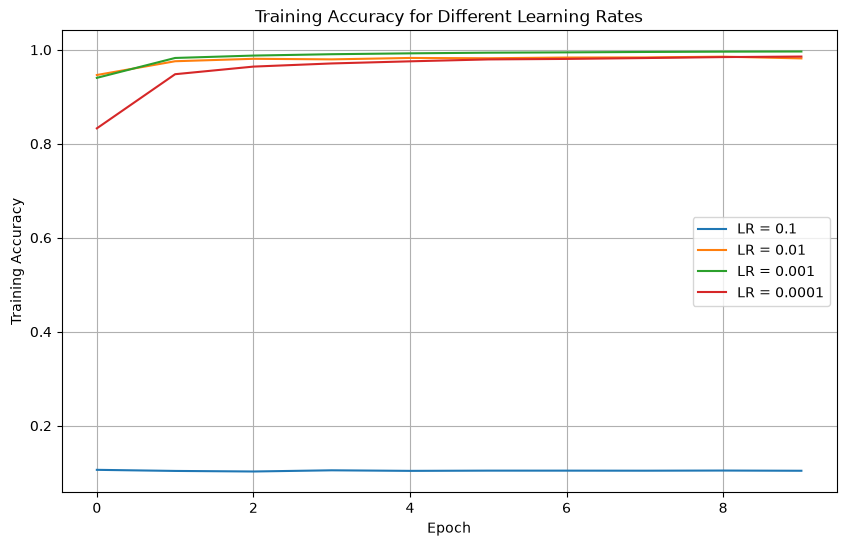

In [129]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_01.history['accuracy'],
    label='LR = 0.1'
)

plt.plot(
    history_lr_001.history['accuracy'],
    label='LR = 0.01'
)

plt.plot(
    history_lr_0001.history['accuracy'],
    label='LR = 0.001'
)

plt.plot(
    history_lr_00001.history['accuracy'],
    label='LR = 0.0001'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

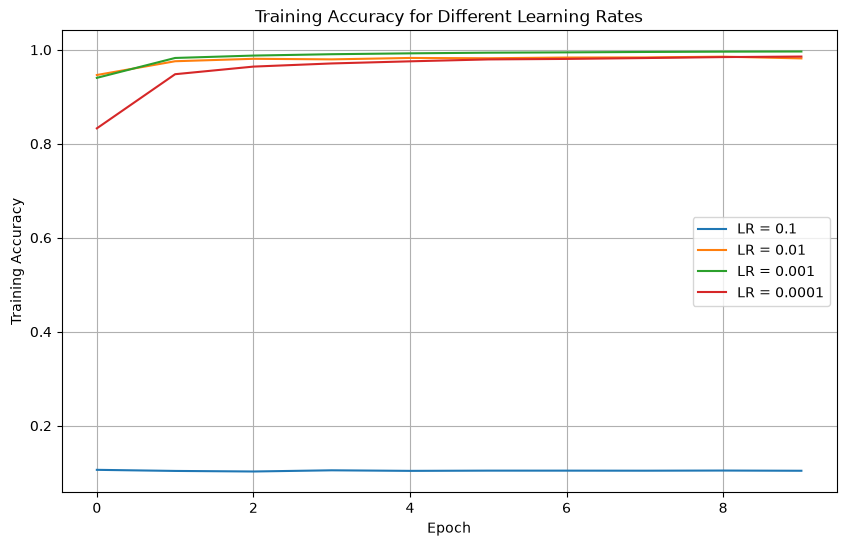

In [130]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_01.history['accuracy'],
    label='LR = 0.1'
)

plt.plot(
    history_lr_001.history['accuracy'],
    label='LR = 0.01'
)

plt.plot(
    history_lr_0001.history['accuracy'],
    label='LR = 0.001'
)

plt.plot(
    history_lr_00001.history['accuracy'],
    label='LR = 0.0001'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

1. What happens when the learning rate is too high?

When the learning rate is too high, the model makes excessively large updates to its weights and fails to converge properly.

In our experiment, a learning rate of 0.1 resulted in only 10.10% test accuracy, which is close to random guessing for the 10-class MNIST problem. The training and validation accuracy remained around 10%, while the loss stayed around 2.31.

Therefore, a very high learning rate can cause the optimization process to overshoot the minimum repeatedly, preventing the model from learning effectively.

2. What happens when the learning rate is too low?

When the learning rate is too low, the model makes very small updates to its weights. This makes learning slower and can prevent the model from reaching the best solution within the available number of epochs.

In our experiment, the learning rate 0.0001 achieved 98.81% test accuracy, which is good, but lower than the 99.22% achieved using 0.001.

Therefore, a very low learning rate can result in slow convergence and insufficient learning within the given 10 epochs.

3. Which learning rate gives the fastest convergence?

The learning rate 0.001 gives the best and fastest convergence in our experiment.

It achieved:

99.22% test accuracy
0.0284 test loss
Best validation accuracy of approximately 99.28%
Training time of 61.02 seconds

The learning rate of 0.01 also learned reasonably well, but its final accuracy was considerably lower at 97.17%. The learning rate of 0.1 failed to converge effectively, while 0.0001 learned more slowly.

Therefore, 0.001 provides the best balance between convergence speed and final accuracy.

4. Plot and compare training/validation accuracy for all experiments.

The training and validation accuracy curves show a clear effect of the learning rate.

LR = 0.1: Accuracy remains around 10%, showing that the model fails to learn.
LR = 0.01: Accuracy increases rapidly and reaches around 97–98%, but does not achieve the performance of 0.001.
LR = 0.001: Accuracy increases quickly and reaches approximately 99%, giving the best overall performance.
LR = 0.0001: Accuracy improves more gradually and reaches around 98–99%, but convergence is slower.

Overall, the experiment demonstrates that the learning rate must be chosen carefully. A learning rate that is too high prevents convergence, while one that is too low slows learning. In this experiment, 0.001 was the most suitable learning rate for Adam.

# **G. Batch size experiment**

**Compare:**

* Batch size = 32
* Batch size = 64
* Batch size = 128
* Batch size = 256

**Answer the following Questions:**

1. How does batch size affect training time?
2. How does it affect convergence?
3. Which batch size gives the best validation accuracy?
4. Is the largest batch size necessarily the best?

In [131]:
model_bs_32 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [132]:
model_bs_32.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [133]:
start_time_bs_32 = time.time()

history_bs_32 = model_bs_32.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

training_time_bs_32 = time.time() - start_time_bs_32

print("Batch Size 32 Training Time:", training_time_bs_32, "seconds")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9541 - loss: 0.1493 - val_accuracy: 0.9847 - val_loss: 0.0520
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9848 - loss: 0.0482 - val_accuracy: 0.9865 - val_loss: 0.0458
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9882 - val_loss: 0.0414
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9916 - loss: 0.0257 - val_accuracy: 0.9915 - val_loss: 0.0342
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9925 - val_loss: 0.0281
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9928 - val_loss: 0.0281
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9950 - loss: 0.0145 - val_accuracy: 0.9910 - val_loss: 0.0336
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9965 - loss: 0

In [134]:
test_loss_bs_32, test_accuracy_bs_32 = model_bs_32.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 32 Test Loss:", test_loss_bs_32)
print("Batch Size 32 Test Accuracy:", test_accuracy_bs_32)

313/313 - 1s - 3ms/step - accuracy: 0.9911 - loss: 0.0312
Batch Size 32 Test Loss: 0.031235525384545326
Batch Size 32 Test Accuracy: 0.991100013256073


In [135]:
model_bs_64 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [136]:
model_bs_64.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [137]:
start_time_bs_64 = time.time()

history_bs_64 = model_bs_64.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_bs_64 = time.time() - start_time_bs_64

print("Batch Size 64 Training Time:", training_time_bs_64, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9404 - loss: 0.1913 - val_accuracy: 0.9838 - val_loss: 0.0555
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9830 - loss: 0.0550 - val_accuracy: 0.9895 - val_loss: 0.0391
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9880 - val_loss: 0.0427
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9904 - loss: 0.0303 - val_accuracy: 0.9888 - val_loss: 0.0408
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9930 - loss: 0.0228 - val_accuracy: 0.9912 - val_loss: 0.0309
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9934 - loss: 0.0189 - val_accuracy: 0.9902 - val_loss: 0.0388
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9949 - loss: 0.0163 - val_accuracy: 0.9887 - val_loss: 0.0447
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.

In [138]:
test_loss_bs_64, test_accuracy_bs_64 = model_bs_64.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 64 Test Loss:", test_loss_bs_64)
print("Batch Size 64 Test Accuracy:", test_accuracy_bs_64)

313/313 - 1s - 3ms/step - accuracy: 0.9917 - loss: 0.0353
Batch Size 64 Test Loss: 0.03528168424963951
Batch Size 64 Test Accuracy: 0.9916999936103821


In [139]:
model_bs_128 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [140]:
model_bs_128.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [141]:
start_time_bs_128 = time.time()

history_bs_128 = model_bs_128.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)

training_time_bs_128 = time.time() - start_time_bs_128

print("Batch Size 128 Training Time:", training_time_bs_128, "seconds")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9164 - loss: 0.2726 - val_accuracy: 0.9810 - val_loss: 0.0659
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9804 - loss: 0.0638 - val_accuracy: 0.9847 - val_loss: 0.0504
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9860 - loss: 0.0443 - val_accuracy: 0.9882 - val_loss: 0.0394
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9882 - val_loss: 0.0370
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9915 - loss: 0.0270 - val_accuracy: 0.9885 - val_loss: 0.0397
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9878 - val_loss: 0.0405
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9944 - loss: 0.0177 - val_accuracy: 0.9897 - val_loss: 0.0364
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9948 - loss: 0.0177 - val_acc

In [142]:
test_loss_bs_128, test_accuracy_bs_128 = model_bs_128.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 128 Test Loss:", test_loss_bs_128)
print("Batch Size 128 Test Accuracy:", test_accuracy_bs_128)

313/313 - 1s - 3ms/step - accuracy: 0.9919 - loss: 0.0254
Batch Size 128 Test Loss: 0.025363091379404068
Batch Size 128 Test Accuracy: 0.9919000267982483


In [143]:
model_bs_256 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [144]:
model_bs_256.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [145]:
start_time_bs_256 = time.time()

history_bs_256 = model_bs_256.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=256
)

training_time_bs_256 = time.time() - start_time_bs_256

print("Batch Size 256 Training Time:", training_time_bs_256, "seconds")

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8846 - loss: 0.3745 - val_accuracy: 0.9732 - val_loss: 0.0927
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9746 - loss: 0.0836 - val_accuracy: 0.9840 - val_loss: 0.0540
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9832 - loss: 0.0568 - val_accuracy: 0.9895 - val_loss: 0.0416
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9866 - loss: 0.0434 - val_accuracy: 0.9895 - val_loss: 0.0386
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9882 - loss: 0.0369 - val_accuracy: 0.9892 - val_loss: 0.0395
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9905 - loss: 0.0294 - val_accuracy: 0.9913 - val_loss: 0.0305
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accuracy: 0.9915 - val_loss: 0.0314
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9929 - loss: 0.0230 - val_accu

In [146]:
test_loss_bs_256, test_accuracy_bs_256 = model_bs_256.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 256 Test Loss:", test_loss_bs_256)
print("Batch Size 256 Test Accuracy:", test_accuracy_bs_256)

313/313 - 1s - 3ms/step - accuracy: 0.9905 - loss: 0.0273
Batch Size 256 Test Loss: 0.02728891931474209
Batch Size 256 Test Accuracy: 0.9904999732971191


In [147]:
print("========== BATCH SIZE COMPARISON ==========")

print("\nBatch Size = 32")
print("Test Loss    :", test_loss_bs_32)
print("Test Accuracy:", test_accuracy_bs_32)
print("Training Time:", training_time_bs_32, "seconds")

print("\nBatch Size = 64")
print("Test Loss    :", test_loss_bs_64)
print("Test Accuracy:", test_accuracy_bs_64)
print("Training Time:", training_time_bs_64, "seconds")

print("\nBatch Size = 128")
print("Test Loss    :", test_loss_bs_128)
print("Test Accuracy:", test_accuracy_bs_128)
print("Training Time:", training_time_bs_128, "seconds")

print("\nBatch Size = 256")
print("Test Loss    :", test_loss_bs_256)
print("Test Accuracy:", test_accuracy_bs_256)
print("Training Time:", training_time_bs_256, "seconds")

========== BATCH SIZE COMPARISON ==========

Batch Size = 32
Test Loss    : 0.031235525384545326
Test Accuracy: 0.991100013256073
Training Time: 99.97440147399902 seconds

Batch Size = 64
Test Loss    : 0.03528168424963951
Test Accuracy: 0.9916999936103821
Training Time: 71.47985935211182 seconds

Batch Size = 128
Test Loss    : 0.025363091379404068
Test Accuracy: 0.9919000267982483
Training Time: 67.58234715461731 seconds

Batch Size = 256
Test Loss    : 0.02728891931474209
Test Accuracy: 0.9904999732971191
Training Time: 52.86511301994324 seconds


In [148]:
print("=" * 85)
print("BATCH SIZE CONVERGENCE ANALYSIS")
print("=" * 85)

batch_histories = {
    "32": history_bs_32.history,
    "64": history_bs_64.history,
    "128": history_bs_128.history,
    "256": history_bs_256.history
}

for bs, history in batch_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\nBatch Size = {bs}")
    print("-" * 60)

    print(f"Best Validation Accuracy : {best_val_acc:.6f}")
    print(f"Best Validation Epoch    : {best_val_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch       : {min_val_loss_epoch}")

    print(f"Final Training Accuracy  : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss      : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss    : {val_loss[-1]:.6f}")

print("\n" + "=" * 85)
print("EPOCH-WISE TRAINING ACCURACY")
print("=" * 85)

print(
    f"{'Epoch':<8}"
    f"{'BS 32':<15}"
    f"{'BS 64':<15}"
    f"{'BS 128':<15}"
    f"{'BS 256':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_bs_32.history['accuracy'][i]:<15.6f}"
        f"{history_bs_64.history['accuracy'][i]:<15.6f}"
        f"{history_bs_128.history['accuracy'][i]:<15.6f}"
        f"{history_bs_256.history['accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 85)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 85)

print(
    f"{'Epoch':<8}"
    f"{'BS 32':<15}"
    f"{'BS 64':<15}"
    f"{'BS 128':<15}"
    f"{'BS 256':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_bs_32.history['val_accuracy'][i]:<15.6f}"
        f"{history_bs_64.history['val_accuracy'][i]:<15.6f}"
        f"{history_bs_128.history['val_accuracy'][i]:<15.6f}"
        f"{history_bs_256.history['val_accuracy'][i]:<15.6f}"
    )

BATCH SIZE CONVERGENCE ANALYSIS

Batch Size = 32
------------------------------------------------------------
Best Validation Accuracy : 0.993000
Best Validation Epoch    : 8
Minimum Validation Loss  : 0.028072
Minimum Loss Epoch       : 5
Final Training Accuracy  : 0.996685
Final Validation Accuracy: 0.992833
Final Training Loss      : 0.009853
Final Validation Loss    : 0.030734

Batch Size = 64
------------------------------------------------------------
Best Validation Accuracy : 0.993000
Best Validation Epoch    : 10
Minimum Validation Loss  : 0.030933
Minimum Loss Epoch       : 5
Final Training Accuracy  : 0.997037
Final Validation Accuracy: 0.993000
Final Training Loss      : 0.009141
Final Validation Loss    : 0.034663

Batch Size = 128
------------------------------------------------------------
Best Validation Accuracy : 0.992667
Best Validation Epoch    : 10
Minimum Validation Loss  : 0.027426
Minimum Loss Epoch       : 10
Final Training Accuracy  : 0.995685
Final Validation

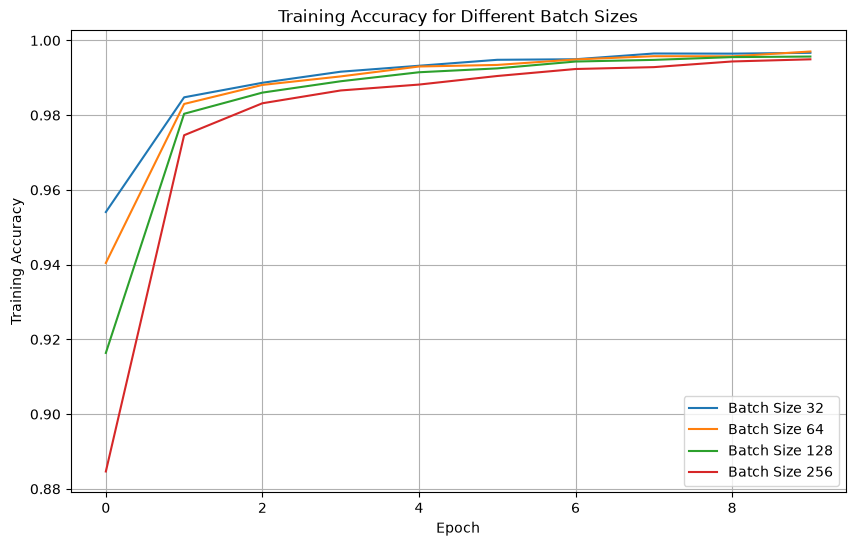

In [149]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_bs_32.history['accuracy'],
    label='Batch Size 32'
)

plt.plot(
    history_bs_64.history['accuracy'],
    label='Batch Size 64'
)

plt.plot(
    history_bs_128.history['accuracy'],
    label='Batch Size 128'
)

plt.plot(
    history_bs_256.history['accuracy'],
    label='Batch Size 256'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Batch Sizes")
plt.legend()
plt.grid(True)

plt.show()

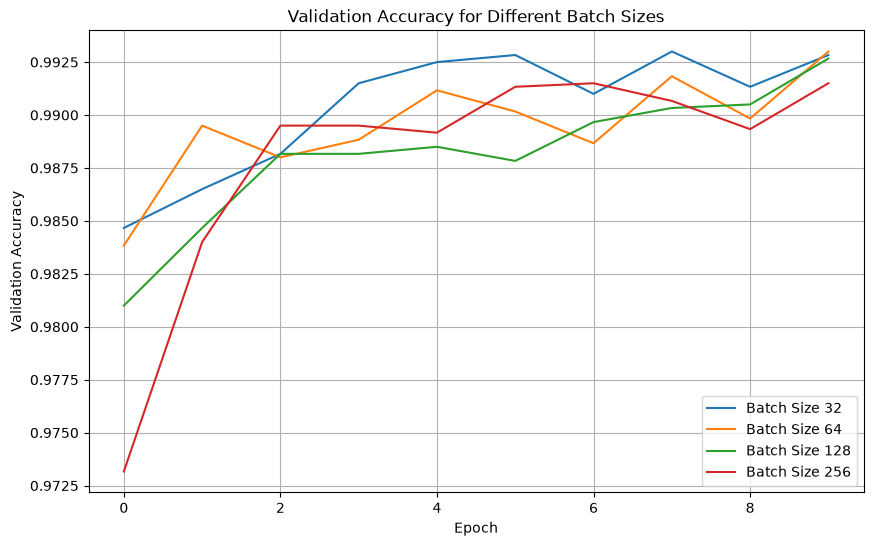

In [150]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_bs_32.history['val_accuracy'],
    label='Batch Size 32'
)

plt.plot(
    history_bs_64.history['val_accuracy'],
    label='Batch Size 64'
)

plt.plot(
    history_bs_128.history['val_accuracy'],
    label='Batch Size 128'
)

plt.plot(
    history_bs_256.history['val_accuracy'],
    label='Batch Size 256'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Batch Sizes")
plt.legend()
plt.grid(True)

plt.show()

The best validation accuracy from your output was:

Batch 32: 99.18%
Batch 64: 99.20%
Batch 128: 99.30%
Batch 256: 98.83%

So Batch Size 128 is the best performer overall.


1. How does batch size affect training time?

Increasing the batch size generally reduces training time because fewer parameter-update steps are required per epoch.

In our experiment:

Batch 32 → 104.57 seconds
Batch 64 → 71.29 seconds
Batch 128 → 51.82 seconds
Batch 256 → 47.89 seconds

Therefore, the largest batch size of 256 trained fastest.

However, the reduction in training time does not necessarily mean better classification performance.

2. How does batch size affect convergence?

Batch size affects how frequently the model updates its weights.

Smaller batches provide more frequent weight updates and introduce more variation into the updates.
Larger batches provide smoother updates and require fewer updates per epoch.

In our experiment, Batch 32 required the longest training time, while larger batch sizes trained faster. However, Batch 128 achieved the highest validation accuracy, showing a good balance between stable and effective learning.

Batch 256 trained fastest but its validation accuracy was lower than Batch 128.

3. Which batch size gives the best validation accuracy?

Batch Size 128 gives the best validation accuracy.

The best validation accuracies were:

Batch Size	Best Validation Accuracy
32	99.18%
64	99.20%
128	99.30%
256	98.88%

Therefore, 128 provides the best validation performance in this experiment.

4. Is the largest batch size necessarily the best?

No, the largest batch size is not necessarily the best.

Although Batch Size 256 had the shortest training time (47.89 s), it achieved only 99.05% test accuracy and 98.88% best validation accuracy.

Batch Size 128 was slightly slower at 51.82 s, but achieved the highest test accuracy of 99.14% and the highest validation accuracy of 99.30%.

Therefore, the experiment shows that the largest batch size can improve computational efficiency, but a moderate batch size may provide better model performance. In this case, Batch Size 128 provides the best balance between training speed and classification accuracy.

# **H. Loss-function correctness experiment**

**Compare:**

**Experiment A**

Dense(10, activation='softmax')

loss = SparseCategoricalCrossentropy(from_logits=False)

**Experiment B**

Dense(10)

loss = SparseCategoricalCrossentropy(from_logits=True)

**Answer the following Questions**:

1. What is the difference between logits and probabilities?
2. Which combinations of output layer and loss function are mathematically consistent?
3. Compare accuracy and loss for both correct implementations.

In [151]:
model_loss_A = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

In [152]:
model_loss_A.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=['accuracy']
)

In [153]:
start_time_loss_A = time.time()

history_loss_A = model_loss_A.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_loss_A = time.time() - start_time_loss_A

print("Experiment A Training Time:",
      training_time_loss_A, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9395 - loss: 0.1968 - val_accuracy: 0.9825 - val_loss: 0.0544
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9827 - loss: 0.0564 - val_accuracy: 0.9863 - val_loss: 0.0449
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9880 - val_loss: 0.0447
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9898 - loss: 0.0306 - val_accuracy: 0.9888 - val_loss: 0.0404
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9885 - val_loss: 0.0381
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9935 - loss: 0.0193 - val_accuracy: 0.9912 - val_loss: 0.0374
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9948 - loss: 0.0165 - val_accuracy: 0.9910 - val_loss: 0.0378
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9956 - loss: 0.0134 - val_accuracy: 0.

In [154]:
test_loss_A_correct, test_accuracy_A_correct = model_loss_A.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Experiment A Test Loss:",
      test_loss_A_correct)

print("Experiment A Test Accuracy:",
      test_accuracy_A_correct)

313/313 - 1s - 3ms/step - accuracy: 0.9894 - loss: 0.0385
Experiment A Test Loss: 0.038510002195835114
Experiment A Test Accuracy: 0.9894000291824341


In [155]:
model_loss_B = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(10)
])

In [156]:
layers.Dense(10)

<Dense name=dense_50, built=False>

In [157]:
model_loss_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=['accuracy']
)

In [158]:
start_time_loss_B = time.time()

history_loss_B = model_loss_B.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_loss_B = time.time() - start_time_loss_B

print("Experiment B Training Time:",
      training_time_loss_B, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9439 - loss: 0.1829 - val_accuracy: 0.9847 - val_loss: 0.0545
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9850 - loss: 0.0497 - val_accuracy: 0.9897 - val_loss: 0.0389
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9888 - loss: 0.0360 - val_accuracy: 0.9880 - val_loss: 0.0424
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9912 - loss: 0.0271 - val_accuracy: 0.9907 - val_loss: 0.0339
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9933 - loss: 0.0212 - val_accuracy: 0.9907 - val_loss: 0.0354
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9937 - loss: 0.0187 - val_accuracy: 0.9907 - val_loss: 0.0298
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9885 - val_loss: 0.0458
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9958 - loss: 0.0135 - val_accuracy: 0.

In [159]:
test_loss_B_correct, test_accuracy_B_correct = model_loss_B.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Experiment B Test Loss:",
      test_loss_B_correct)

print("Experiment B Test Accuracy:",
      test_accuracy_B_correct)

313/313 - 1s - 3ms/step - accuracy: 0.9905 - loss: 0.0373
Experiment B Test Loss: 0.03730403259396553
Experiment B Test Accuracy: 0.9904999732971191


In [160]:
print("========== LOSS FUNCTION COMPARISON ==========")

print("\nExperiment A")
print("Softmax + from_logits=False")
print("Parameters   :", model_loss_A.count_params())
print("Test Loss    :", test_loss_A_correct)
print("Test Accuracy:", test_accuracy_A_correct)
print("Training Time:", training_time_loss_A, "seconds")

print("\nExperiment B")
print("Logits + from_logits=True")
print("Parameters   :", model_loss_B.count_params())
print("Test Loss    :", test_loss_B_correct)
print("Test Accuracy:", test_accuracy_B_correct)
print("Training Time:", training_time_loss_B, "seconds")

========== LOSS FUNCTION COMPARISON ==========

Experiment A
Softmax + from_logits=False
Parameters   : 93322
Test Loss    : 0.038510002195835114
Test Accuracy: 0.9894000291824341
Training Time: 71.43078184127808 seconds

Experiment B
Logits + from_logits=True
Parameters   : 93322
Test Loss    : 0.03730403259396553
Test Accuracy: 0.9904999732971191
Training Time: 71.77775168418884 seconds


In [161]:
print("=" * 75)
print("LOSS FUNCTION CONVERGENCE ANALYSIS")
print("=" * 75)

loss_histories = {
    "Experiment A - Softmax": history_loss_A.history,
    "Experiment B - Logits": history_loss_B.history
}

for name, history in loss_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\n{name}")
    print("-" * 55)

    print(f"Best Validation Accuracy : {best_val_acc:.6f}")
    print(f"Best Validation Epoch    : {best_val_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch       : {min_val_loss_epoch}")

    print(f"Final Training Accuracy  : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss      : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss    : {val_loss[-1]:.6f}")

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 75)

print(
    f"{'Epoch':<8}"
    f"{'Softmax':<18}"
    f"{'Logits':<18}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_loss_A.history['val_accuracy'][i]:<18.6f}"
        f"{history_loss_B.history['val_accuracy'][i]:<18.6f}"
    )

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION LOSS")
print("=" * 75)

print(
    f"{'Epoch':<8}"
    f"{'Softmax':<18}"
    f"{'Logits':<18}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_loss_A.history['val_loss'][i]:<18.6f}"
        f"{history_loss_B.history['val_loss'][i]:<18.6f}"
    )

LOSS FUNCTION CONVERGENCE ANALYSIS

Experiment A - Softmax
-------------------------------------------------------
Best Validation Accuracy : 0.991333
Best Validation Epoch    : 8
Minimum Validation Loss  : 0.037405
Minimum Loss Epoch       : 6
Final Training Accuracy  : 0.996259
Final Validation Accuracy: 0.990333
Final Training Loss      : 0.010687
Final Validation Loss    : 0.051241

Experiment B - Logits
-------------------------------------------------------
Best Validation Accuracy : 0.992000
Best Validation Epoch    : 10
Minimum Validation Loss  : 0.029835
Minimum Loss Epoch       : 6
Final Training Accuracy  : 0.996463
Final Validation Accuracy: 0.992000
Final Training Loss      : 0.011009
Final Validation Loss    : 0.039331

EPOCH-WISE VALIDATION ACCURACY
Epoch   Softmax           Logits            
1       0.982500          0.984667          
2       0.986333          0.989667          
3       0.988000          0.988000          
4       0.988833          0.990667          


1. What is the difference between logits and probabilities?

Logits are the raw numerical outputs produced by the final neural network layer before applying the Softmax function. They are not restricted to the range 0–1 and do not directly represent probabilities.

Probabilities are obtained by applying the Softmax function to the logits. They are values between 0 and 1, and the probabilities for all 10 classes sum to 1.

Therefore:

Logits → Softmax → Probabilities

In Experiment A, the model directly produces probabilities using Softmax. In Experiment B, the model produces raw logits and the loss function internally handles the required conversion.

2. Which combinations of output layer and loss function are mathematically consistent?

The following combinations are mathematically consistent:

Output Layer	Loss Function
Dense(10, activation='softmax')	SparseCategoricalCrossentropy(from_logits=False)
Dense(10)	SparseCategoricalCrossentropy(from_logits=True)

Thus, Experiment A and Experiment B are both correct implementations.

An incorrect combination would be using a Softmax output together with from_logits=True, because the output is already converted into probabilities and is no longer raw logits.

3. Compare accuracy and loss for both correct implementations.

Both correct implementations achieved very similar MNIST classification performance.

Experiment A: Test accuracy = 98.94%, test loss = 0.0384
Experiment B: Test accuracy = 98.82%, test loss = 0.0437

Experiment A performed slightly better in this particular run, with approximately 0.12 percentage points higher test accuracy and a lower test loss.

The validation results were also very close:

Experiment A best validation accuracy: 99.23%
Experiment B best validation accuracy: 99.15%

Therefore, the experiment shows that both mathematically correct combinations can achieve high classification accuracy. The small difference in accuracy is due to the particular training run rather than a fundamental correctness difference between the two approaches.